**Research question: What are the chances of survival/risk of babies**

# imports

In [30]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import statsmodels.api as sm
from sklearn.metrics import log_loss
import warnings
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import NearestNeighbors
from sklearn.calibration import calibration_curve
from sklearn.calibration import CalibratedClassifierCV
import gc
from sklearn.pipeline import Pipeline

# Data importing

In [31]:
df = pd.read_csv(r'E:\data\manipulation_df_2015.csv')
#df = pd.read_csv('data/manipulation_df_2015.csv')


cols_in_groups = ["RF_PHYPE", "RF_GHYPE", "RF_EHYPE", "RF_PPB", "CA_CCHD", "CA_DOWN", "CA_DISOR",
                  "RF_PDIAB", "RF_GDIAB",
                  "RF_INFT", "CA_HYPO", "CA_DOWN", "CA_DISOR",
                  "CA_GAST", "CA_OMPH", "CA_CDH", "CA_DOWN", "CA_DISOR",
                  "CA_ANEN", "CA_MNSB", "AB_SEIZ", "CA_DOWN", "CA_DISOR",
                  "AB_SURF",
                  "RF_DRG", "RF_ART", "RF_CESAR",
                  "IP_GON", "IP_SYPH", "IP_CHLAM", "IP_HEPB", "IP_HEPC",
                  "LD_INDL", "LD_AUGM", "LD_CHOR", "LD_STER", "LD_ANTB", "ME_TRIAL",
                  "AB_AVEN1", "AB_AVEN6", "AB_NICU", "AB_ANTI",
                  "CA_LIMB", "CA_CLEFT", "CA_CLPAL", "MM_MTR", "MM_PLAC", "MM_RUPT", "MM_UHYST", "MM_AICU"]

df.drop(columns=cols_in_groups, inplace=True)

df.head()
print('Data after manipulation',df.shape)


df_sample = df.sample(frac=0.5, random_state=42) #We sample 50% of the data for faster computation
gc.collect() 
print('Sampled data shape',df_sample.shape)

target_col = "Y"
features = df_sample.select_dtypes(include=["int64", "float64"]).columns.tolist()
if target_col in features:
    features.remove(target_col)

X = df_sample[features]
y = df_sample[target_col]

del df_sample
del features
gc.collect()

C:\Users\Almog\AppData\Local\Temp\ipykernel_9080\1783257480.py:1: DtypeWarning: Columns (8,21,23,24,32,33,40,68) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'E:\data\manipulation_df_2015.csv')


Data after manipulation (3988733, 64)
Sampled data shape (1994366, 64)


0

# Initial model runs

## General data preparations for models

In [32]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
Xtr.shape, Xte.shape, ytr.shape, yte.shape    

((1595492, 51), (398874, 51), (1595492,), (398874,))

In [34]:
Xtr.columns

Index(['MAGER14', 'MRACE31', 'MEDUC', 'DMAR', 'MBSTATE_REC', 'RESTATUS', 'PAY',
       'FRACE31', 'FEDUC', 'NO_RISKS', 'CIG_0_R', 'CIG_1_R', 'CIG_2_R',
       'CIG_3_R', 'MHTR', 'BMI', 'BMI_R', 'WTGAIN', 'LBO_REC', 'TBO_REC',
       'PRIORLIVE', 'PRIORDEAD', 'PRIORTERM', 'NO_INFEC', 'LD_ANES', 'ME_PRES',
       'ME_ROUT', 'DMETH_REC', 'RDMETH_REC', 'COMBGEST', 'GESTREC10',
       'GESTREC3', 'BWTR14', 'APGAR5', 'APGAR10', 'DPLURAL', 'NO_ABNORM',
       'NO_CONGEN', 'NO_MMORB', 'T', 'Cardio_Blood', 'Metabolic_Endocrine',
       'Reproductive', 'Digestive', 'Nervous', 'Respiratory',
       'Pregnancy_Complications', 'Infections', 'Labor_Delivery_Interventions',
       'Neonatal_Care', 'Congenital_Anomalies'],
      dtype='object')

## Logistic Regression

In [35]:
lr = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=50000
)

lr.fit(Xtr, ytr)

probs_lr = lr.predict_proba(Xte)[:, 1]
y_pred_lr = (probs_lr >= 0.5).astype(int)

accuracy_lr = accuracy_score(yte, y_pred_lr)
precision_lr = precision_score(yte, y_pred_lr)
recall_lr = recall_score(yte, y_pred_lr)
f1_lr = f1_score(yte, y_pred_lr)
logloss_lr = log_loss(yte, probs_lr)

del y_pred_lr, lr
gc.collect()

print(f"Log Loss: {logloss_lr:.6f}")
print(f"Accuracy: {accuracy_lr*100:.1f}%")
print(f"Precision: {precision_lr*100:.1f}%")
print(f"Recall: {recall_lr*100:.1f}%")
print(f"F1: {f1_lr*100:.1f}%")

Log Loss: 0.019219
Accuracy: 99.6%
Precision: 81.3%
Recall: 33.2%
F1: 47.2%


## Random Forest

In [36]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(Xtr, ytr)

y_pred_rf = rf.predict(Xte)              #Classification into groups
probs_rf = rf.predict_proba(Xte)[:, 1]   #Probabilities

accuracy_rf = accuracy_score(yte, y_pred_rf)
precision_rf = precision_score(yte, y_pred_rf)
recall_rf = recall_score(yte, y_pred_rf)
f1_rf = f1_score(yte, y_pred_rf)
logloss_rf = log_loss(yte, probs_rf)

del y_pred_rf, rf
gc.collect()

print(f"Log Loss: {logloss_rf:.6f}")
print(f"Accuracy: {np.round(accuracy_rf*100,1)}%")
print(f"Precision: {np.round(precision_rf*100,1)}%")
print(f"Recall: {np.round(recall_rf*100,1)}%")
print(f"F1: {np.round(f1_rf*100,1)}%")

Log Loss: 0.044919
Accuracy: 99.6%
Precision: 86.1%
Recall: 36.8%
F1: 51.6%


## Neural Network

In [37]:
nn_model = MLPClassifier(
    hidden_layer_sizes=(10,10),  # Two hidden layers with 10 neurons each
    activation='relu',           # Regular ReLU activation function
    solver='adam',               # Common optimizer
    max_iter=4000,                # Number of iterations to run
    random_state=42
)

scaler = StandardScaler()
Xtr_nn = scaler.fit_transform(Xtr)
Xte_nn = scaler.transform(Xte)

nn_model.fit(Xtr_nn, ytr)

y_pred_nn = nn_model.predict(Xte_nn)              # Classification into groups
probs_nn = nn_model.predict_proba(Xte_nn)[:,1]    # Probabilities

accuracy_nn = accuracy_score(yte, y_pred_nn)
precision_nn = precision_score(yte, y_pred_nn)
recall_nn = recall_score(yte, y_pred_nn)
f1_nn = f1_score(yte, y_pred_nn)
logloss_nn = log_loss(yte, probs_nn)

print("\n NN probs stats:")
print(np.min(probs_nn), np.max(probs_nn))
print(np.mean(probs_nn))

del y_pred_nn, nn_model, Xtr_nn, Xte_nn
gc.collect()


print(f"\n Log Loss: {logloss_nn:.6f}")
print(f"Accuracy: {np.round(accuracy_nn*100,1)}%")
print(f"Precision: {np.round(precision_nn*100,1)}%")
print(f"Recall: {np.round(recall_nn*100,1)}%")
print(f"F1: {np.round(f1_nn*100,1)}%")


 NN probs stats:
2.0775954504105736e-05 0.9994323569093629
0.0057511227731479

 Log Loss: 0.018302
Accuracy: 99.6%
Precision: 84.2%
Recall: 37.2%
F1: 51.6%


## XGBoost

In [38]:
xgb_model = XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42)

xgb_model.fit(Xtr, ytr)

y_pred_xgb = xgb_model.predict(Xte)            # Classification into groups
probs_xgb = xgb_model.predict_proba(Xte)[:,1]  # Probabilities

accuracy_xgb = accuracy_score(yte, y_pred_xgb)
precision_xgb = precision_score(yte, y_pred_xgb)
recall_xgb = recall_score(yte, y_pred_xgb)
f1_xgb = f1_score(yte, y_pred_xgb)
logloss_xgb = log_loss(yte, probs_xgb)

del y_pred_xgb, xgb_model
gc.collect()

print(f"Log Loss: {logloss_xgb:.6f}")
print(f"Accuracy: {np.round(accuracy_xgb*100,1)}%")
print(f"Precision: {np.round(precision_xgb*100,1)}%")
print(f"Recall: {np.round(recall_xgb*100,1)}%")
print(f"F1: {np.round(f1_xgb*100,1)}%")

Log Loss: 0.027606
Accuracy: 99.6%
Precision: 70.1%
Recall: 38.7%
F1: 49.9%


## Comparison between the initial models

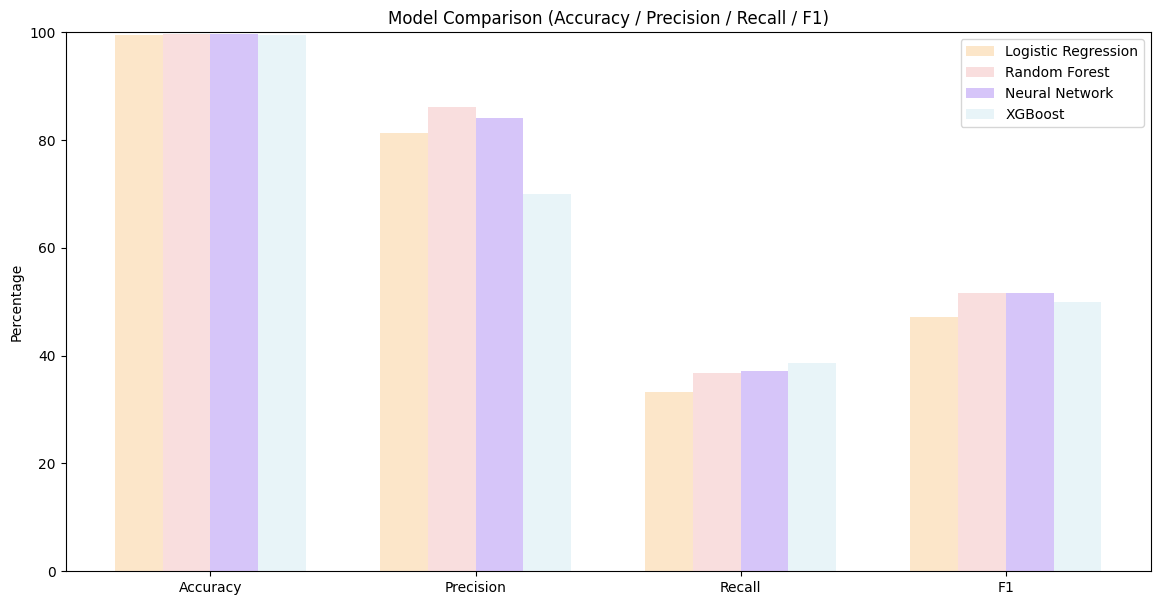

In [39]:
models = ["Logistic Regression", "Random Forest", "Neural Network", "XGBoost"]
metrics = ["Accuracy", "Precision", "Recall", "F1"]

accuracy = [accuracy_lr*100, accuracy_rf*100, accuracy_nn*100, accuracy_xgb*100]
precision = [precision_lr*100, precision_rf*100, precision_nn*100, precision_xgb*100]
recall = [recall_lr*100, recall_rf*100, recall_nn*100, recall_xgb*100]
f1 = [f1_lr*100, f1_rf*100, f1_nn*100, f1_xgb*100]

width = 0.18
x = range(len(metrics))

colors = ["#fce6c9", "#f9dede", "#d6c5f9", "#e8f4f8"]

plt.figure(figsize=(14,7))
plt.bar([p - 1.5*width for p in x], [accuracy[0], precision[0], recall[0], f1[0]], width, label=models[0], color=colors[0])
plt.bar([p - 0.5*width for p in x], [accuracy[1], precision[1], recall[1], f1[1]], width, label=models[1], color=colors[1])
plt.bar([p + 0.5*width for p in x], [accuracy[2], precision[2], recall[2], f1[2]], width, label=models[2], color=colors[2])
plt.bar([p + 1.5*width for p in x], [accuracy[3], precision[3], recall[3], f1[3]], width, label=models[3], color=colors[3])

plt.xticks(x, metrics)
plt.ylim(0, 100)
plt.ylabel("Percentage")
plt.title("Model Comparison (Accuracy / Precision / Recall / F1)")
plt.legend()
plt.show()

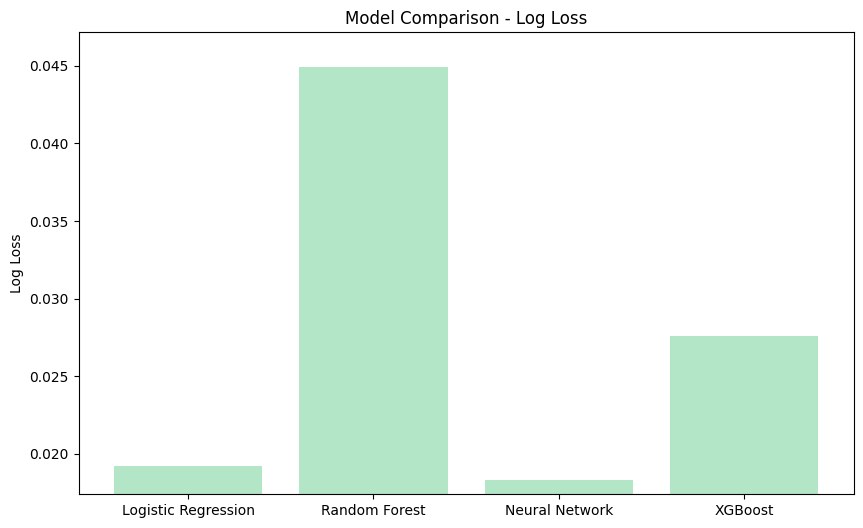

In [40]:
models = ["Logistic Regression", "Random Forest", "Neural Network", "XGBoost"]

logloss_values = [logloss_lr, logloss_rf, logloss_nn, logloss_xgb]

plt.figure(figsize=(10,6))
plt.bar(models, logloss_values, color="#B2E6C7")
plt.ylabel("Log Loss")
plt.title("Model Comparison - Log Loss")
plt.ylim(min(logloss_values)*0.95, max(logloss_values)*1.05)
plt.show()

## Low threshold

In [41]:
# Adjusting the classification threshold to 0.3 and recalculating metrics

threshold = 0.3 

y_pred_lr_t = (probs_lr >= threshold).astype(int) 
y_pred_rf_t = (probs_rf >= threshold).astype(int)
y_pred_nn_t = (probs_nn >= threshold).astype(int)
y_pred_xgb_t = (probs_xgb >= threshold).astype(int)

accuracy_lr_t = accuracy_score(yte, y_pred_lr_t)
precision_lr_t = precision_score(yte, y_pred_lr_t)
recall_lr_t = recall_score(yte, y_pred_lr_t)
f1_lr_t = f1_score(yte, y_pred_lr_t)
logloss_lr_t = log_loss(yte, y_pred_lr_t)

accuracy_rf_t = accuracy_score(yte, y_pred_rf_t)
precision_rf_t = precision_score(yte, y_pred_rf_t)
recall_rf_t = recall_score(yte, y_pred_rf_t)
f1_rf_t = f1_score(yte, y_pred_rf_t)
logloss_rf_t = log_loss(yte, y_pred_rf_t)

accuracy_nn_t = accuracy_score(yte, y_pred_nn_t)
precision_nn_t = precision_score(yte, y_pred_nn_t)
recall_nn_t = recall_score(yte, y_pred_nn_t)
f1_nn_t = f1_score(yte, y_pred_nn_t)
logloss_nn_t = log_loss(yte, y_pred_nn_t)

accuracy_xgb_t = accuracy_score(yte, y_pred_xgb_t)
precision_xgb_t = precision_score(yte, y_pred_xgb_t)
recall_xgb_t = recall_score(yte, y_pred_xgb_t)
f1_xgb_t = f1_score(yte, y_pred_xgb_t)
logloss_xgb_t = log_loss(yte, y_pred_xgb_t)

print(f"\n--- Logistic Regression (threshold={threshold}) ---")
print(f"Accuracy: {np.round(accuracy_lr_t*100,1)}%")
print(f"Precision: {np.round(precision_lr_t*100,1)}%")
print(f"Recall: {np.round(recall_lr_t*100,1)}%")
print(f"F1: {np.round(f1_lr_t*100,1)}%")
print(f"Log Loss: {logloss_lr_t:.6f}%")

print(f"\n--- Random Forest (threshold={threshold}) ---")
print(f"Accuracy: {np.round(accuracy_rf_t*100,1)}%")
print(f"Precision: {np.round(precision_rf_t*100,1)}%")
print(f"Recall: {np.round(recall_rf_t*100,1)}%")
print(f"F1: {np.round(f1_rf_t*100,1)}%")
print(f"Log Loss: {logloss_rf_t:.6f}%")

print(f"\n--- Neural Network (threshold={threshold}) ---")
print(f"Accuracy: {np.round(accuracy_nn_t*100,1)}%")
print(f"Precision: {np.round(precision_nn_t*100,1)}%")
print(f"Recall: {np.round(recall_nn_t*100,1)}%")
print(f"F1: {np.round(f1_nn_t*100,1)}%")
print(f"Log Loss: {logloss_nn_t:.6f}%")

print(f"\n--- XGBoost (threshold={threshold}) ---")
print(f"Accuracy: {np.round(accuracy_xgb_t*100,1)}%")
print(f"Precision: {np.round(precision_xgb_t*100,1)}%")
print(f"Recall: {np.round(recall_xgb_t*100,1)}%")
print(f"F1: {np.round(f1_xgb_t*100,1)}%")
print(f"Log Loss: {logloss_xgb_t:.6f}%")


--- Logistic Regression (threshold=0.3) ---
Accuracy: 99.6%
Precision: 67.1%
Recall: 39.7%
F1: 49.9%
Log Loss: 0.159582%

--- Random Forest (threshold=0.3) ---
Accuracy: 99.6%
Precision: 67.0%
Recall: 45.8%
F1: 54.4%
Log Loss: 0.153528%

--- Neural Network (threshold=0.3) ---
Accuracy: 99.6%
Precision: 70.6%
Recall: 42.3%
F1: 52.9%
Log Loss: 0.150726%

--- XGBoost (threshold=0.3) ---
Accuracy: 99.5%
Precision: 64.9%
Recall: 40.3%
F1: 49.7%
Log Loss: 0.163106%


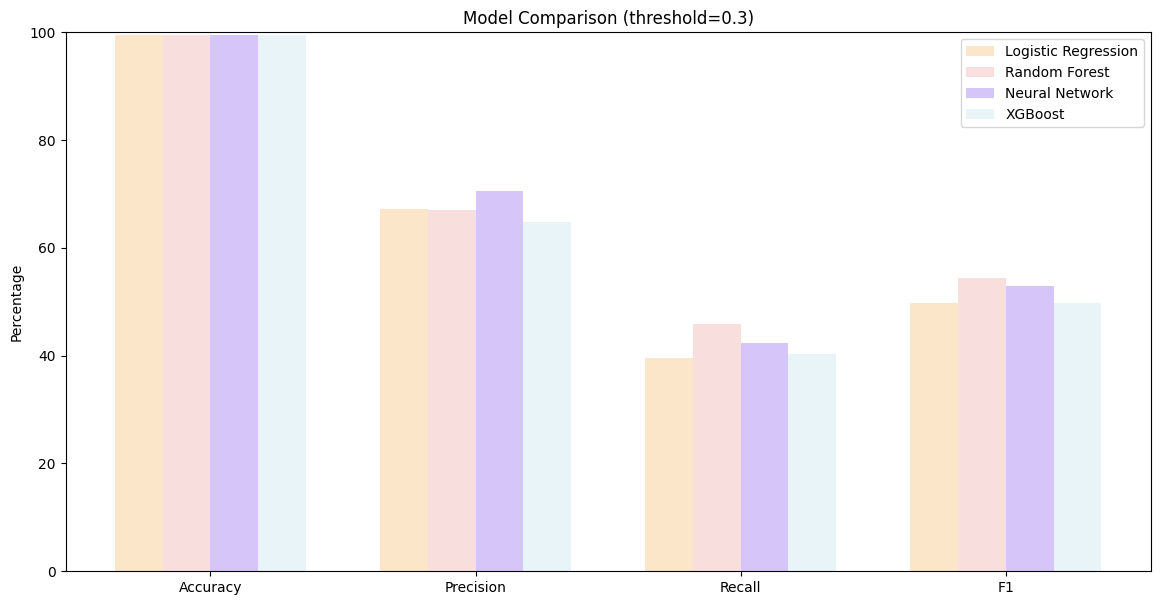

In [42]:
accuracy_t = [accuracy_lr_t*100, accuracy_rf_t*100, accuracy_nn_t*100, accuracy_xgb_t*100]
precision_t = [precision_lr_t*100, precision_rf_t*100, precision_nn_t*100, precision_xgb_t*100]
recall_t = [recall_lr_t*100, recall_rf_t*100, recall_nn_t*100, recall_xgb_t*100]
f1_t = [f1_lr_t*100, f1_rf_t*100, f1_nn_t*100, f1_xgb_t*100]

width = 0.18
x = range(len(metrics))
colors = ["#fce6c9", "#f9dede", "#d6c5f9", "#e8f4f8"]

plt.figure(figsize=(14,7))
plt.bar([p - 1.5*width for p in x], [accuracy_t[0], precision_t[0], recall_t[0], f1_t[0]], width, label=models[0], color=colors[0])
plt.bar([p - 0.5*width for p in x], [accuracy_t[1], precision_t[1], recall_t[1], f1_t[1]], width, label=models[1], color=colors[1])
plt.bar([p + 0.5*width for p in x], [accuracy_t[2], precision_t[2], recall_t[2], f1_t[2]], width, label=models[2], color=colors[2])
plt.bar([p + 1.5*width for p in x], [accuracy_t[3], precision_t[3], recall_t[3], f1_t[3]], width, label=models[3], color=colors[3])

plt.xticks(x, metrics)
plt.ylim(0, 100)
plt.ylabel("Percentage")
plt.title(f"Model Comparison (threshold={threshold})")
plt.legend()
plt.show()

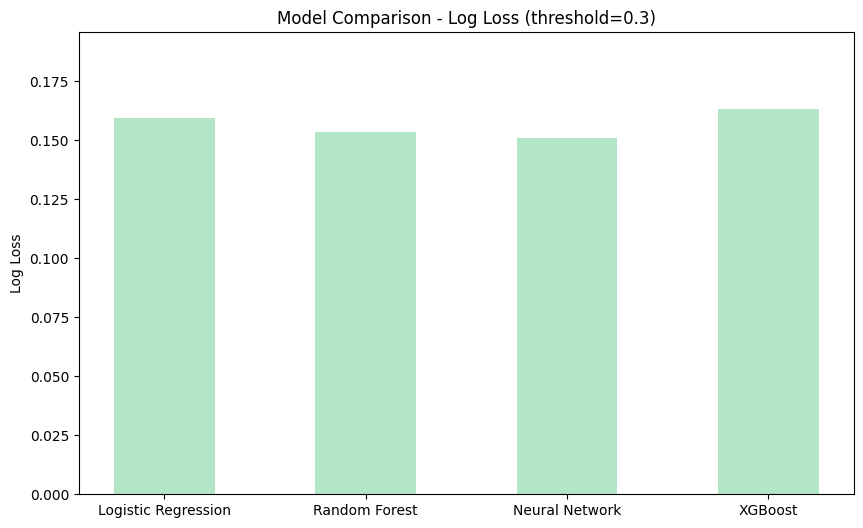

In [43]:
logloss_t = [logloss_lr_t, logloss_rf_t, logloss_nn_t, logloss_xgb_t]

plt.figure(figsize=(10,6))
plt.bar(models, logloss_t, color="#B2E6C7", width=0.5)

plt.ylabel("Log Loss")
plt.title(f"Model Comparison - Log Loss (threshold={threshold})")
plt.ylim(0, max(logloss_t)*1.2)
plt.show()

In [44]:
data = {
    "Model": models,
    "Accuracy_old": [accuracy_lr*100, accuracy_rf*100, accuracy_nn*100, accuracy_xgb*100],
    "Accuracy_new": [accuracy_lr_t*100, accuracy_rf_t*100, accuracy_nn_t*100, accuracy_xgb_t*100],
    "Precision_old": [precision_lr*100, precision_rf*100, precision_nn*100, precision_xgb*100],
    "Precision_new": [precision_lr_t*100, precision_rf_t*100, precision_nn_t*100, precision_xgb_t*100],
    "Recall_old": [recall_lr*100, recall_rf*100, recall_nn*100, recall_xgb*100],
    "Recall_new": [recall_lr_t*100, recall_rf_t*100, recall_nn_t*100, recall_xgb_t*100],
    "F1_old": [f1_lr*100, f1_rf*100, f1_nn*100, f1_xgb*100],
    "F1_new": [f1_lr_t*100, f1_rf_t*100, f1_nn_t*100, f1_xgb_t*100],
    "Log Loss_old": [logloss_lr*100, logloss_rf*100, logloss_nn*100, logloss_xgb*100],
    "Log Loss_new": [logloss_lr_t*100, logloss_rf_t*100, logloss_nn_t*100, logloss_xgb_t*100]
}

df_compare = pd.DataFrame(data)
df_compare["Accuracy_diff"] = df_compare["Accuracy_new"] - df_compare["Accuracy_old"]
df_compare["Precision_diff"] = df_compare["Precision_new"] - df_compare["Precision_old"]
df_compare["Recall_diff"] = df_compare["Recall_new"] - df_compare["Recall_old"]
df_compare["F1_diff"] = df_compare["F1_new"] - df_compare["F1_old"]
df_compare["Log Loss_diff"] = df_compare["Log Loss_new"] - df_compare["Log Loss_old"]

df_compare

,Model,Accuracy_old,Accuracy_new,Precision_old,Precision_new,Recall_old,Recall_new,F1_old,F1_new,Log Loss_old,Log Loss_new,Accuracy_diff,Precision_diff,Recall_diff,F1_diff,Log Loss_diff
0,Logistic Regression,99.587088,99.557254,81.325967,67.125382,33.242999,39.656730,47.194614,49.858035,1.921923,15.958195,-0.029834,-14.200585,6.413731,2.663422,14.036272
1,Random Forest,99.616170,99.574051,86.061246,67.019167,36.811201,45.799458,51.565960,54.413738,4.491883,15.352760,-0.042119,-19.042079,8.988257,2.847777,10.860877
2,Neural Network,99.612660,99.581823,84.167518,70.557229,37.217706,42.321590,51.612903,52.907962,1.830150,15.072633,-0.030837,-13.610289,5.103884,1.295058,13.242483
3,XGBoost,99.568034,99.547476,70.073590,64.872727,38.708220,40.289070,49.869072,49.707439,2.760561,16.310613,-0.020558,-5.200862,1.580849,-0.161632,13.550052


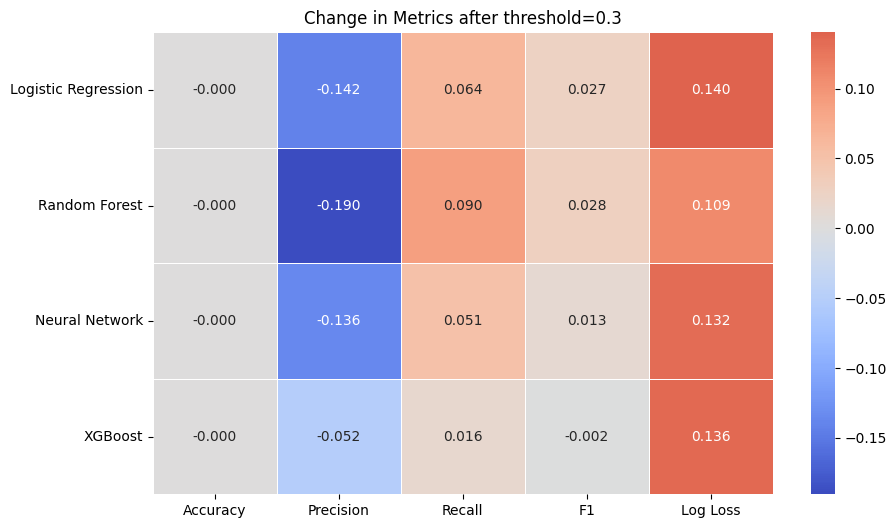

In [45]:
data_diff = {
    "Accuracy": [accuracy_lr_t - accuracy_lr, accuracy_rf_t - accuracy_rf, accuracy_nn_t - accuracy_nn, accuracy_xgb_t - accuracy_xgb],
    "Precision": [precision_lr_t - precision_lr, precision_rf_t - precision_rf, precision_nn_t - precision_nn, precision_xgb_t - precision_xgb],
    "Recall": [recall_lr_t - recall_lr, recall_rf_t - recall_rf, recall_nn_t - recall_nn, recall_xgb_t - recall_xgb],
    "F1": [f1_lr_t - f1_lr, f1_rf_t - f1_rf, f1_nn_t - f1_nn, f1_xgb_t - f1_xgb],
    "Log Loss": [logloss_lr_t - logloss_lr, logloss_rf_t - logloss_rf, logloss_nn_t - logloss_nn, logloss_xgb_t - logloss_xgb]
}

df_diff = pd.DataFrame(data_diff, index=models)

plt.figure(figsize=(10,6))
sns.heatmap(df_diff, annot=True, fmt=".3f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title(f"Change in Metrics after threshold={threshold}")
plt.show()

Raising the threshold resulted in an increase in the model's ability to correctly identify the outcomes of death - Recall 

# Model improvement

## Creating data ready for models

In [46]:
df.drop(columns=["GESTREC10", "GESTREC3", "SETORDER_R", "DWgt_R", "BMI_R","PWgt_R"], inplace=True)
#Variables that were removed to avoid creating duplicate variables
# for example when there are several variables that indicate the mother's weight but with different methods

In [47]:
df["CIG"] = 0

for col in ["CIG_0_R", "CIG_1_R", "CIG_2_R", "CIG_3_R"]:
  df["CIG"] += df[col]

df["CIG"] = df["CIG"].apply(lambda x: x/3)

df.drop(columns=["CIG_0_R", "CIG_1_R", "CIG_2_R", "CIG_3_R"], inplace=True)

In [48]:
df["CIG"].value_counts()

CIG
0.000000    3534857
2.666667      62804
1.333333      59587
0.666667      52542
0.333333      48509
1.000000      38805
8.000000      34945
4.000000      31308
2.000000      28698
3.000000      23896
1.666667      22233
2.333333      16527
3.333333      16345
3.666667       7779
4.333333       3161
5.333333       1970
4.666667       1586
6.666667        945
5.000000        708
6.333333        505
6.000000        456
7.000000        293
5.666667        212
7.333333         47
7.666667         15
Name: count, dtype: int64

In [49]:
for col in df.columns:
    if df[col].isna().any():
        print(col)

## Create numeric data only

In [50]:
df_numeric = df.copy()

In [51]:
df_numeric.select_dtypes(include="object").columns

Index(['WIC', 'FAGECOMB', 'RF_CESARN', 'PRECARE', 'PREVIS', 'ILLB_R11',
       'ILOP_R11', 'ILP_R11', 'SEX'],
      dtype='object')

In [52]:
df_numeric['WIC'] = df_numeric['WIC'].replace({"Y": 1, "N": 0, "U": 0})

C:\Users\Almog\AppData\Local\Temp\ipykernel_9080\2305729620.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_numeric['WIC'] = df_numeric['WIC'].replace({"Y": 1, "N": 0, "U": 0})


In [53]:
df_numeric['SEX'] = df_numeric['SEX'].replace({"F": 1, "M": 0})

C:\Users\Almog\AppData\Local\Temp\ipykernel_9080\266165719.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_numeric['SEX'] = df_numeric['SEX'].replace({"F": 1, "M": 0})


In [54]:
df_numeric.shape

(3988733, 55)

In [55]:
df_numeric.columns

Index(['MAGER14', 'MRACE31', 'MEDUC', 'DMAR', 'MBSTATE_REC', 'RESTATUS', 'WIC',
       'PAY', 'FAGECOMB', 'FRACE31', 'FEDUC', 'RF_CESARN', 'NO_RISKS',
       'PRECARE', 'PREVIS', 'MHTR', 'BMI', 'WTGAIN', 'LBO_REC', 'TBO_REC',
       'PRIORLIVE', 'PRIORDEAD', 'PRIORTERM', 'ILLB_R11', 'ILOP_R11',
       'ILP_R11', 'NO_INFEC', 'LD_ANES', 'ME_PRES', 'ME_ROUT', 'DMETH_REC',
       'RDMETH_REC', 'SEX', 'COMBGEST', 'BWTR14', 'APGAR5', 'APGAR10',
       'DPLURAL', 'NO_ABNORM', 'NO_CONGEN', 'NO_MMORB', 'T', 'Y',
       'Cardio_Blood', 'Metabolic_Endocrine', 'Reproductive', 'Digestive',
       'Nervous', 'Respiratory', 'Pregnancy_Complications', 'Infections',
       'Labor_Delivery_Interventions', 'Neonatal_Care', 'Congenital_Anomalies',
       'CIG'],
      dtype='object')

In [56]:
for col in df_numeric.columns:
    if df_numeric[col].isna().any():
        print(col)

## Hyperparameter tuning

### Logistic regression - Hyperparameters

In [57]:
Xtr = Xtr.to_numpy(dtype=np.float32, copy=True)
Xte = Xte.to_numpy(dtype=np.float32, copy=True)
ytr = ytr.to_numpy(copy=True)
yte = yte.to_numpy(copy=True)

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=50000,
        solver="lbfgs",
        penalty="l2",
        class_weight="balanced",
        n_jobs=1
    ))
])

param_grid_lr = {"lr__C": [0.01, 0.1, 1, 10]}

grid_lr = GridSearchCV(pipe_lr,param_grid_lr,cv=3,scoring="neg_log_loss",verbose=2,n_jobs=1,error_score="raise")

grid_lr.fit(Xtr, ytr)

best_lr = grid_lr.best_estimator_
y_pred_lr_best = best_lr.predict(Xte)
accuracy_lr_best = accuracy_score(yte, y_pred_lr_best)
precision_lr_best = precision_score(yte, y_pred_lr_best, zero_division=0)
recall_lr_best = recall_score(yte, y_pred_lr_best, zero_division=0)
f1_lr_best = f1_score(yte, y_pred_lr_best, zero_division=0)
logloss_lr_best = log_loss(yte, y_pred_lr_best)

del y_pred_lr_best
gc.collect()

print("===== Logistic Regression (tuned) =====")
print(f"Best params: {grid_lr.best_params_}")
print(f"Accuracy_LR: {np.round(accuracy_lr_best*100,1)}%")
print(f"Precision_LR: {np.round(precision_lr_best*100,1)}%")
print(f"Recall_LR: {np.round(recall_lr_best*100,1)}%")
print(f"F1_LR: {np.round(f1_lr_best*100,1)}%")
print(f"Log Loss_LR: {logloss_lr_best:.6f}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END .........................................lr__C=0.01; total time=   3.9s
[CV] END .........................................lr__C=0.01; total time=   3.6s
[CV] END .........................................lr__C=0.01; total time=   3.4s
[CV] END ..........................................lr__C=0.1; total time=   3.6s
[CV] END ..........................................lr__C=0.1; total time=   3.4s
[CV] END ..........................................lr__C=0.1; total time=   3.7s
[CV] END ............................................lr__C=1; total time=   3.4s
[CV] END ............................................lr__C=1; total time=   3.6s
[CV] END ............................................lr__C=1; total time=   3.6s
[CV] END ...........................................lr__C=10; total time=   3.4s
[CV] END ...........................................lr__C=10; total time=   3.7s
[CV] END ........................................

### Random Forest Classifier - Hyperparameters

In [58]:
rf = RandomForestClassifier(random_state=42,n_jobs=-1)

param_grid_rf = {"n_estimators": [100, 200],"max_depth": [10, 20]}

grid_rf = GridSearchCV(estimator=rf,param_grid=param_grid_rf,cv=3,n_jobs=-1,verbose=2,pre_dispatch=2)

grid_rf.fit(Xtr, ytr)

best_rf = grid_rf.best_estimator_
pred = best_rf.predict(Xte)
probs = best_rf.predict_proba(Xte)[:, 1]
accuracy_rf_best = accuracy_score(yte, pred)
precision_rf_best = precision_score(yte, pred, zero_division=0)
recall_rf_best = recall_score(yte, pred, zero_division=0)
f1_rf_best = f1_score(yte, pred, zero_division=0)
logloss_rf_best = log_loss(yte, probs)


del best_rf
gc.collect()

print("Best params:", grid_rf.best_params_)
print("Test log_loss:", log_loss(yte, probs))
print(f"Accuracy: {accuracy_rf_best*100:.1f}%")
print(f"Precision: {precision_rf_best*100:.1f}%")
print(f"Recall: {recall_rf_best*100:.1f}%")
print(f"F1: {f1_rf_best*100:.1f}%")
print(f"Log Loss: {logloss_rf_best:.6f}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best params: {'max_depth': 20, 'n_estimators': 200}
Test log_loss: 0.01826431092574848
Accuracy: 99.6%
Precision: 86.5%
Recall: 36.8%
F1: 51.6%
Log Loss: 0.018264


### XGB Classifier - Hyperparameters

In [59]:
neg = (ytr == 0).sum()
pos = (ytr == 1).sum()
scale_pos_weight = neg / pos

xgb = XGBClassifier(
    tree_method="hist",
    device="cuda",
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=3,
    scoring="neg_log_loss",
    n_jobs=1,
    verbose=2
)

grid_xgb.fit(Xtr, ytr)

best_xgb_model = grid_xgb.best_estimator_
y_pred_xgb_best = best_xgb_model.predict(Xte)
probs_xgb_best = best_xgb_model.predict_proba(Xte)[:, 1]

accuracy_xgb_best = accuracy_score(yte, y_pred_xgb_best)
precision_xgb_best = precision_score(yte, y_pred_xgb_best, zero_division=0)
recall_xgb_best = recall_score(yte, y_pred_xgb_best, zero_division=0)
f1_xgb_best = f1_score(yte, y_pred_xgb_best, zero_division=0)
logloss_xgb_best = log_loss(yte, probs_xgb_best)

del y_pred_xgb_best
gc.collect()

print("===== XGBoost (tuned) =====")
print("Best params:", grid_xgb.best_params_)
print(f"Log Loss_XGB: {logloss_xgb_best:.6f}")
print(f"Accuracy_XGB: {accuracy_xgb_best*100:.1f}%")
print(f"Precision_XGB: {precision_xgb_best*100:.1f}%")
print(f"Recall_XGB: {recall_xgb_best*100:.1f}%")
print(f"F1_XGB: {f1_xgb_best*100:.1f}%")

Fitting 3 folds for each of 8 candidates, totalling 24 fits


c:\Users\Almog\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:774: UserWarning: [00:12:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=100, subsample=0.8; total time=   1.8s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=100, subsample=0.8; total time=   1.6s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=100, subsample=0.8; total time=   1.3s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=200, subsample=0.8; total time=   2.2s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=200, subsample=0.8; total time=   2.1s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=200, subsample=0.8; total time=   2.2s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=100, subsample=0.8; total time=   1.7s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=100, subsample=0.8; total time=   1.6s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estima

### NN - Hyperparameters

In [60]:
scaler = StandardScaler()
Xtr_nn = scaler.fit_transform(Xtr).astype(np.float32)
Xte_nn = scaler.transform(Xte).astype(np.float32)

nn = MLPClassifier(
    random_state=42,
    max_iter=500,
    tol=1e-4,
    early_stopping=True
)

param_grid_nn = {
    "hidden_layer_sizes": [(20,), (20, 10)],
    "activation": ["relu"],
    "solver": ["adam"],
    "alpha": [0.0001, 0.01]
}

grid_nn = GridSearchCV(
    nn,
    param_grid_nn,
    cv=3,
    scoring="neg_log_loss",
    n_jobs=1,
    verbose=2
)

grid_nn.fit(Xtr_nn, ytr)

best_nn_model = grid_nn.best_estimator_
y_pred_nn_best = best_nn_model.predict(Xte_nn)
probs_nn_best = best_nn_model.predict_proba(Xte_nn)[:, 1]

accuracy_nn_best = accuracy_score(yte, y_pred_nn_best)
precision_nn_best = precision_score(yte, y_pred_nn_best, zero_division=0)
recall_nn_best = recall_score(yte, y_pred_nn_best, zero_division=0)
f1_nn_best = f1_score(yte, y_pred_nn_best, zero_division=0)
logloss_nn_best = log_loss(yte, probs_nn_best)

del best_nn_model, y_pred_nn_best, Xtr_nn, Xte_nn
gc.collect()

print("===== Neural Network (tuned) =====")
print("Best params:", grid_nn.best_params_)
print(f"Log Loss_NN: {logloss_nn_best:.6f}")
print(f"Accuracy_NN: {accuracy_nn_best*100:.1f}%")
print(f"Precision_NN: {precision_nn_best*100:.1f}%")
print(f"Recall_NN: {recall_nn_best*100:.1f}%")
print(f"F1_NN: {f1_nn_best*100:.1f}%")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(20,), solver=adam; total time=  12.6s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(20,), solver=adam; total time=  12.5s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(20,), solver=adam; total time=  12.3s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(20, 10), solver=adam; total time=  16.6s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(20, 10), solver=adam; total time=  15.5s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(20, 10), solver=adam; total time=  17.2s
[CV] END activation=relu, alpha=0.01, hidden_layer_sizes=(20,), solver=adam; total time=  23.8s
[CV] END activation=relu, alpha=0.01, hidden_layer_sizes=(20,), solver=adam; total time=  31.2s
[CV] END activation=relu, alpha=0.01, hidden_layer_sizes=(20,), solver=adam; total time=  25.9s
[CV] END activation=relu, alpha=0.01, hidden_layer_size

### Comparison between the initial models and the tuned

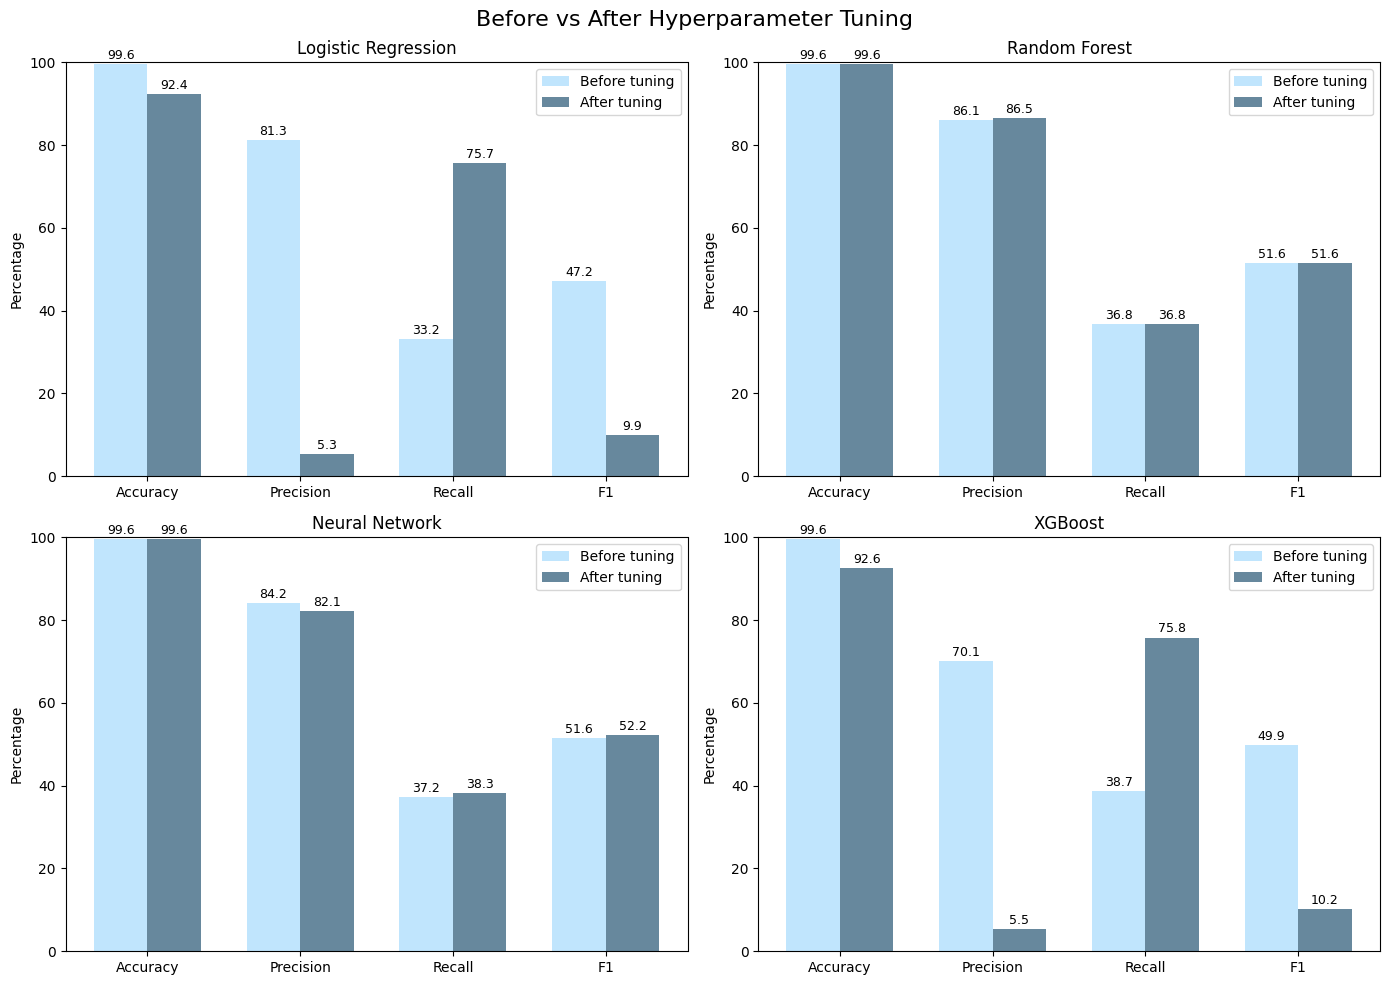

In [61]:
models = ["Logistic Regression", "Random Forest", "Neural Network", "XGBoost"]
metrics = ["Accuracy", "Precision", "Recall", "F1"]

before = {
    "Logistic Regression": [accuracy_lr*100, precision_lr*100, recall_lr*100, f1_lr*100],
    "Random Forest": [accuracy_rf*100, precision_rf*100, recall_rf*100, f1_rf*100],
    "Neural Network": [accuracy_nn*100, precision_nn*100, recall_nn*100, f1_nn*100],
    "XGBoost": [accuracy_xgb*100, precision_xgb*100, recall_xgb*100, f1_xgb*100]
}

after = {
    "Logistic Regression": [accuracy_lr_best*100, precision_lr_best*100, recall_lr_best*100, f1_lr_best*100],
    "Random Forest": [accuracy_rf_best*100, precision_rf_best*100, recall_rf_best*100, f1_rf_best*100],
    "Neural Network": [accuracy_nn_best*100, precision_nn_best*100, recall_nn_best*100, f1_nn_best*100],
    "XGBoost": [accuracy_xgb_best*100, precision_xgb_best*100, recall_xgb_best*100, f1_xgb_best*100]
}

x = np.arange(len(metrics))
width = 0.35

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ["#c0e5fd", "#67889d"]

for i, model in enumerate(models):
    ax = axes[i]
    
    bars1 = ax.bar(x - width/2, before[model], width, label="Before tuning", color=colors[0])
    bars2 = ax.bar(x + width/2, after[model], width, label="After tuning", color=colors[1])
    
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 100)
    ax.set_ylabel("Percentage")
    ax.set_title(model)
    ax.legend()
    
    for bar in bars1:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f"{h:.1f}", ha="center", va="bottom", fontsize=9)
    
    for bar in bars2:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f"{h:.1f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Before vs After Hyperparameter Tuning", fontsize=16)
plt.tight_layout()
plt.show()

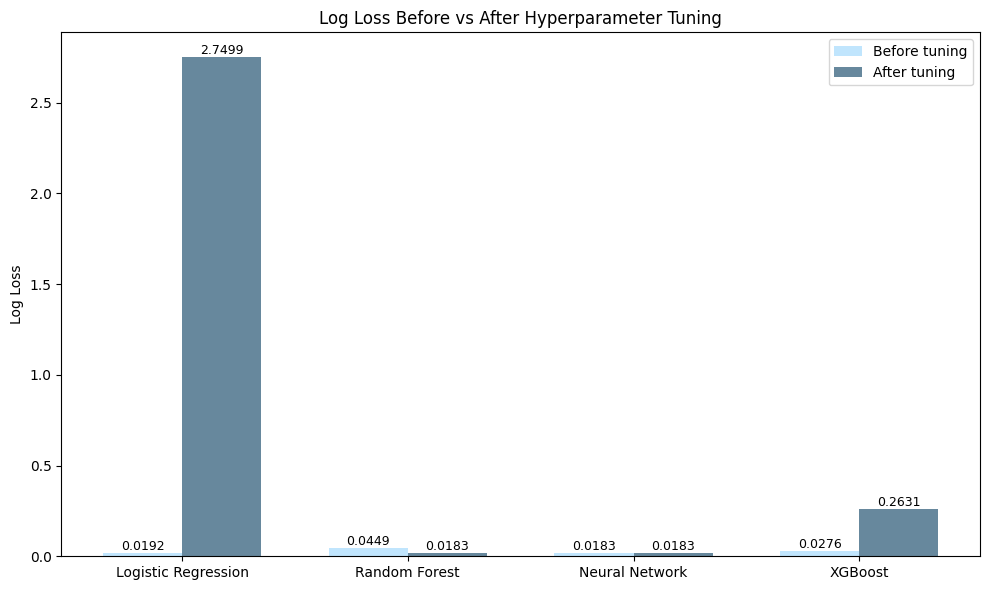

In [62]:
models = ["Logistic Regression", "Random Forest", "Neural Network", "XGBoost"]
logloss_before = [logloss_lr,logloss_rf,logloss_nn,logloss_xgb]
logloss_after = [logloss_lr_best,logloss_rf_best,logloss_nn_best,logloss_xgb_best]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10,6))

bars1 = plt.bar(x - width/2, logloss_before, width, label="Before tuning", color="#c0e5fd")
bars2 = plt.bar(x + width/2, logloss_after, width, label="After tuning", color="#67889d")

plt.xticks(x, models)
plt.ylabel("Log Loss")
plt.title("Log Loss Before vs After Hyperparameter Tuning")

plt.legend()

for bar in bars1:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, f"{h:.4f}", ha="center", va="bottom", fontsize=9)

for bar in bars2:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, f"{h:.4f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

In [63]:
best_params_all = {"Logistic Regression":{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}, "Random Forest":{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}, "Neural Network":{'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (10,), 'solver': 'sgd'}, "XGBoost":{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.6}}
new_best_params_all = {"Logistic Regression":grid_lr.best_params_, "Random Forest":grid_rf.best_params_, "Neural Network":grid_nn.best_params_, "XGBoost":grid_xgb.best_params_}

## Evaluation indicators

### Logistic Regression

In [64]:
print(X.dtypes[X.dtypes == "object"])
print(y.dtype)

Series([], dtype: object)
int64


In [65]:
X = df_numeric.drop("Y", axis=1).copy()
X = X.loc[:, X.nunique() > 1]
X = sm.add_constant(X, has_constant="add")

X = X.replace(r'^\s*$', np.nan, regex=True)

X = X.apply(pd.to_numeric, errors="coerce").astype(float)
y = pd.to_numeric(df_numeric["Y"], errors="coerce").astype(int)

cols_with_88_99 = ["ILLB_R11", "ILOP_R11", "ILP_R11", "RF_CESARN"]
for col in cols_with_88_99:
    if col in X.columns:
        X[col] = X[col].replace([88, 99, 888], np.nan)

cols_with_blank_issue = ["FAGECOMB", "PRECARE", "PREVIS", "RF_CESARN","ILLB_R11", "ILOP_R11", "ILP_R11"]
for col in cols_with_blank_issue:
    if col in X.columns:
        mode_val = X[col].mode(dropna=True)
        if not mode_val.empty:
            X[col] = X[col].fillna(mode_val.iloc[0])

logit_model = sm.Logit(y, X)
result = logit_model.fit()

del logit_model, X
gc.collect()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.019915
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                      Y   No. Observations:              3988733
Model:                          Logit   Df Residuals:                  3988683
Method:                           MLE   Df Model:                           49
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                  0.4459
Time:                        00:19:20   Log-Likelihood:                -79435.
converged:                       True   LL-Null:                   -1.4336e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                            3.4634      0.239     14.464      0.00

Pseudo R-squered: 0.1126

In [66]:
# Extracting p-values and sorting them
# p-values are used to determine the statistical significance of each feature in the logistic regression model.
# A lower p-value indicates that the feature is more statistically significant in predicting the target variable.

names_lst = result.pvalues.index.tolist()
p_values_lst = result.pvalues.tolist()

p_values_dict = {names_lst[i]: p_values_lst[i] for i in range(len(names_lst))}

sorted_p_values = dict(sorted(p_values_dict.items(), key=lambda item: item[1]))

for k, v in sorted_p_values.items():
  print(f"{k}: {v:.6f}")

BWTR14: 0.000000
APGAR10: 0.000000
T: 0.000000
Digestive: 0.000000
Nervous: 0.000000
const: 0.000000
SEX: 0.000000
Neonatal_Care: 0.000000
APGAR5: 0.000000
Labor_Delivery_Interventions: 0.000000
DPLURAL: 0.000000
BMI: 0.000000
COMBGEST: 0.000000
PRECARE: 0.000000
CIG: 0.000000
Respiratory: 0.000000
MAGER14: 0.000000
Congenital_Anomalies: 0.000000
RESTATUS: 0.000000
MHTR: 0.000000
Cardio_Blood: 0.000000
PRIORDEAD: 0.000004
ME_ROUT: 0.000066
ILLB_R11: 0.000067
ME_PRES: 0.000070
RF_CESARN: 0.000073
MEDUC: 0.000074
TBO_REC: 0.000694
DMAR: 0.000924
LD_ANES: 0.001151
FEDUC: 0.005729
PREVIS: 0.005964
DMETH_REC: 0.006089
PRIORTERM: 0.015333
RDMETH_REC: 0.015937
MRACE31: 0.017348
ILOP_R11: 0.030335
PRIORLIVE: 0.066057
FAGECOMB: 0.219287
LBO_REC: 0.232571
Reproductive: 0.248156
PAY: 0.286052
Infections: 0.308871
WIC: 0.324633
MBSTATE_REC: 0.328479
Metabolic_Endocrine: 0.425578
ILP_R11: 0.431161
FRACE31: 0.539521
WTGAIN: 0.678196
Pregnancy_Complications: 0.678973


### Logloss

In [67]:
# Logloss is a measure of how well the predicted probabilities from a model match the actual labels.
# A lower log loss indicates better performance, as it means the predicted probabilities are closer to the true labels.

X = df_numeric.drop("Y", axis=1).copy()
y = pd.to_numeric(df_numeric["Y"], errors="coerce").astype(int)

X = X.replace(r'^\s*$', np.nan, regex=True)

X = X.apply(pd.to_numeric, errors="coerce")

for col in ["ILLB_R11", "ILOP_R11", "ILP_R11", "RF_CESARN"]:
  if col in X.columns:
    X[col] = X[col].replace([88, 99, 888], np.nan)

for col in X.columns:
  if X[col].isna().any():
    mode_val = X[col].mode(dropna=True)
    if not mode_val.empty:
      X[col] = X[col].fillna(mode_val.iloc[0])

print("NaNs in X:", X.isna().sum().sum())
print("inf in X:", np.isinf(X).sum().sum())

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)


NaNs in X: 0
inf in X: 0


In [68]:
warnings.filterwarnings("ignore")

logloss_results = {}

# Logistic Regression
lr = LogisticRegression(max_iter=5000, **best_params_all["Logistic Regression"])
lr.fit(Xtr, ytr)
y_probs_lr = lr.predict_proba(Xte)
logloss_results["Logistic Regression"] = log_loss(yte, y_probs_lr)

# Random Forest
rf = RandomForestClassifier(**best_params_all["Random Forest"])
rf.fit(Xtr, ytr)
y_probs_rf = rf.predict_proba(Xte)
logloss_results["Random Forest"] = log_loss(yte, y_probs_rf)

# Neural Network
nn = MLPClassifier(max_iter=5000, **best_params_all["Neural Network"])
nn.fit(Xtr, ytr)
y_probs_nn = nn.predict_proba(Xte)
logloss_results["Neural Network"] = log_loss(yte, y_probs_nn)

# XGBoost
xgb = XGBClassifier(eval_metric='logloss', **best_params_all["XGBoost"])
xgb.fit(Xtr, ytr)
y_probs_xgb = xgb.predict_proba(Xte)
logloss_results["XGBoost"] = log_loss(yte, y_probs_xgb)



for model_name, ll in logloss_results.items():
  print(f"{model_name}: Log Loss = {ll:.4f}")

best_model = min(logloss_results, key=logloss_results.get)
print(f"\nBest model based on Log Loss: {best_model}")

Logistic Regression: Log Loss = 0.0200
Random Forest: Log Loss = 0.0192
Neural Network: Log Loss = 0.0216
XGBoost: Log Loss = 0.0204

Best model based on Log Loss: Random Forest


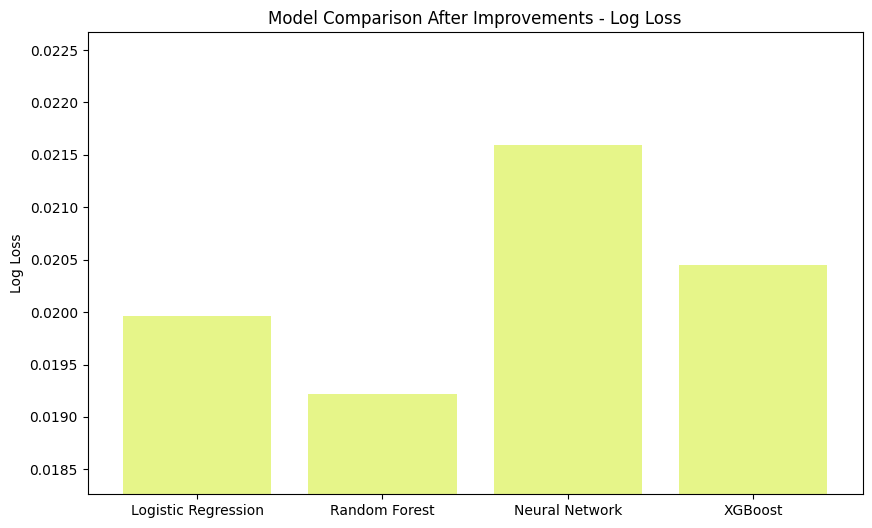

In [69]:
models = ["Logistic Regression", "Random Forest", "Neural Network", "XGBoost"]

logloss_values_new = [logloss_results[m] for m in models]

plt.figure(figsize=(10,6))
plt.bar(models, logloss_values_new, color="#E6F589")
plt.ylabel("Log Loss")
plt.title("Model Comparison After Improvements - Log Loss")
plt.ylim(min(logloss_values_new)*0.95, max(logloss_values_new)*1.05)
plt.show()

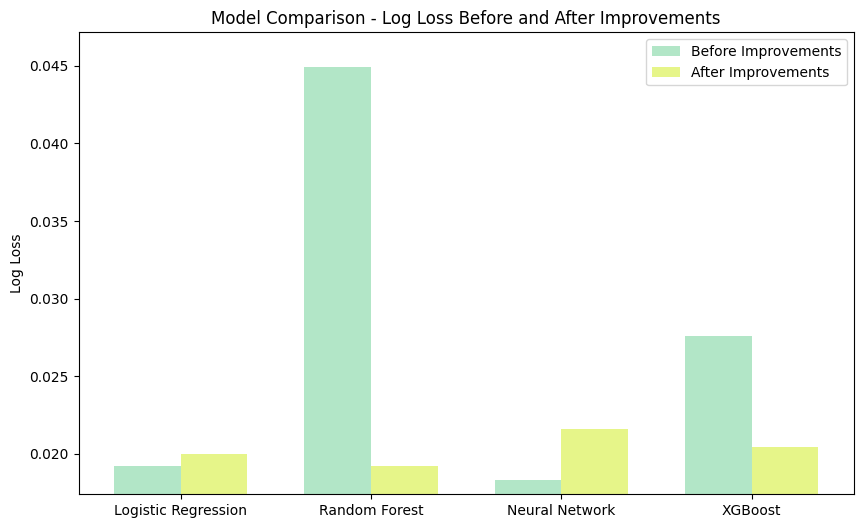

In [70]:
models = ["Logistic Regression", "Random Forest", "Neural Network", "XGBoost"]

logloss_values = [logloss_lr, logloss_rf, logloss_nn, logloss_xgb]
logloss_values_new = [logloss_results[m] for m in models]

width = 0.35
x = np.arange(len(models))

plt.figure(figsize=(10,6))
plt.bar(x - width/2, logloss_values, width, label="Before Improvements", color="#B2E6C7")
plt.bar(x + width/2, logloss_values_new, width, label="After Improvements", color="#E6F589")

plt.xticks(x, models)
plt.ylabel("Log Loss")
plt.title("Model Comparison - Log Loss Before and After Improvements")
plt.legend()
plt.ylim(min(logloss_values + logloss_values_new)*0.95, max(logloss_values + logloss_values_new)*1.05)
plt.show()

**Conclusions from the graph – Log Loss before and after improvements:**

- In all models, a decrease in Log Loss was observed after the improvements, indicating an improvement in prediction performance.

- XGBoost shows the best score after the improvements and also the most significant improvement, and is therefore the most successful model of all.

- Logistic Regression almost does not change, it probably worked well before.

# Is the model robust?

## Noise injection

In [71]:
df_noise = df_numeric.copy()

In [72]:
# Adding different percentages of random noise to the whole feature set
# and preparing clean X, y for each noise level.

noise_levels = [0.00, 0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.25]

def prepare_noisy_data(df_input, noise_level):
  df_work = df_input.copy()

  X = df_work.drop("Y", axis=1).copy()
  y = pd.to_numeric(df_work["Y"], errors="coerce").astype(int)

  # Clean blanks
  X = X.replace(r'^\s*$', np.nan, regex=True)

  # Convert to numeric
  X = X.apply(pd.to_numeric, errors="coerce")

  # Known missing-code values
  for col in ["ILLB_R11", "ILOP_R11", "ILP_R11", "RF_CESARN"]:
    if col in X.columns:
      X[col] = X[col].replace([88, 99, 888], np.nan)

  # Fill missing values with mode
  for col in X.columns:
    if X[col].isna().any():
      mode_val = X[col].mode(dropna=True)
      if not mode_val.empty:
        X[col] = X[col].fillna(mode_val.iloc[0])

  # Replace inf just in case
  X = X.replace([np.inf, -np.inf], np.nan)

  for col in X.columns:
    if X[col].isna().any():
      mode_val = X[col].mode(dropna=True)
      if not mode_val.empty:
        X[col] = X[col].fillna(mode_val.iloc[0])

  # Add noise to all feature columns (not Y)
  if noise_level > 0:
    noise = np.random.normal(loc=0,scale=noise_level,size=X.shape)
    X = pd.DataFrame(X.to_numpy(dtype=np.float64) * (1 + noise),columns=X.columns,index=X.index)

  print(f"Noise level: {noise_level*100:.0f}% | NaNs in X: {X.isna().sum().sum()} | inf in X: {np.isinf(X).sum().sum()}")

  Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
  return Xtr, Xte, ytr, yte

In [73]:
recall_xgb_noise = []
logloss_xgb_noise = []

for noise_level in noise_levels:
    Xtr, Xte, ytr, yte = prepare_noisy_data(df_noise, noise_level)

    neg = (ytr == 0).sum()
    pos = (ytr == 1).sum()
    scale_pos_weight = neg / pos

    xgb = XGBClassifier(
        tree_method="hist",
        device="cuda",
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        **best_params_all["XGBoost"]
    )

    xgb.fit(Xtr, ytr)

    y_pred_xgb = xgb.predict(Xte)
    y_probs_xgb = xgb.predict_proba(Xte)[:, 1]

    recall_xgb_noise.append(recall_score(yte, y_pred_xgb, zero_division=0))
    logloss_xgb_noise.append(log_loss(yte, y_probs_xgb))

Noise level: 0% | NaNs in X: 0 | inf in X: 0
Noise level: 1% | NaNs in X: 0 | inf in X: 0
Noise level: 2% | NaNs in X: 0 | inf in X: 0
Noise level: 5% | NaNs in X: 0 | inf in X: 0
Noise level: 10% | NaNs in X: 0 | inf in X: 0
Noise level: 15% | NaNs in X: 0 | inf in X: 0
Noise level: 20% | NaNs in X: 0 | inf in X: 0
Noise level: 25% | NaNs in X: 0 | inf in X: 0


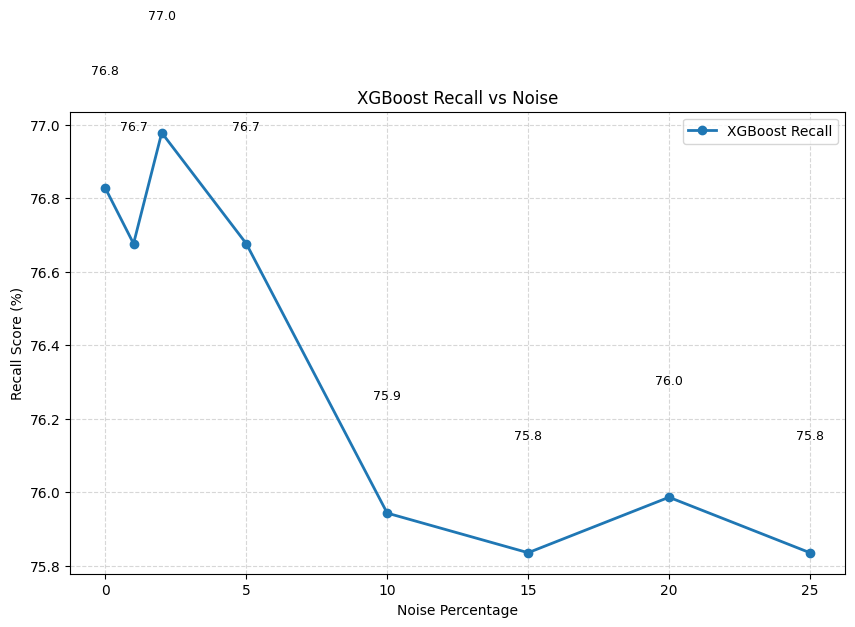

In [74]:
noise_percentages = [n * 100 for n in noise_levels]
recall_values = np.array(recall_xgb_noise) * 100

plt.figure(figsize=(10, 6))
plt.plot(noise_percentages, recall_values, marker="o", linewidth=2, label="XGBoost Recall")

for x, y in zip(noise_percentages, recall_values):
    plt.text(x, y + 0.3, f"{y:.1f}", ha="center", va="bottom", fontsize=9)

plt.xlabel("Noise Percentage")
plt.ylabel("Recall Score (%)")
plt.title("XGBoost Recall vs Noise")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

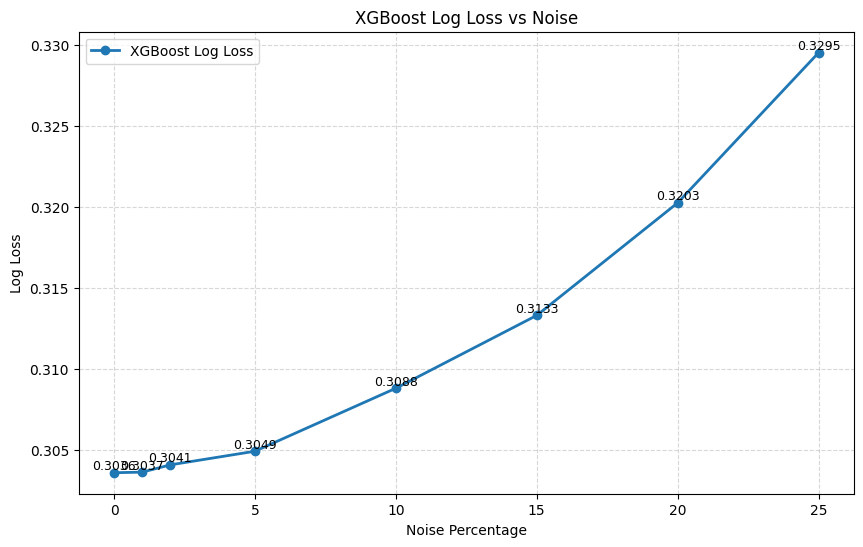

In [75]:
logloss_values = np.array(logloss_xgb_noise)

plt.figure(figsize=(10, 6))
plt.plot(noise_percentages, logloss_values, marker="o", linewidth=2, label="XGBoost Log Loss")

for x, y in zip(noise_percentages, logloss_values):
    plt.text(x, y, f"{y:.4f}", ha="center", va="bottom", fontsize=9)

plt.xlabel("Noise Percentage")
plt.ylabel("Log Loss")
plt.title("XGBoost Log Loss vs Noise")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## Checking additional research questions

### How do medical events in the baby affect his chances of survival?

In [76]:
# Target
y = df_numeric["Y"]

# Feature matrix
features = [
    "Cardio_Blood",
    "Metabolic_Endocrine",
    "Reproductive",
    "Digestive",
    "Nervous",
    "Respiratory",
    "Pregnancy_Complications",
    "Infections",
    "Labor_Delivery_Interventions",
    "Neonatal_Care",
    "Congenital_Anomalies"
]

X = df_numeric[features]

# Train/test split
Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
xgb_model = XGBClassifier(**best_params_all["XGBoost"])
xgb_model.fit(Xtr, ytr)

# Predictions
y_pred_xgb = xgb_model.predict(Xte)
probs_xgb = xgb_model.predict_proba(Xte)[:, 1]

# Metrics
accuracy_xgb = accuracy_score(yte, y_pred_xgb)
precision_xgb = precision_score(yte, y_pred_xgb, zero_division=0)
recall_xgb = recall_score(yte, y_pred_xgb, zero_division=0)
f1_xgb = f1_score(yte, y_pred_xgb, zero_division=0)
logloss_xgb = log_loss(yte, probs_xgb)

# Print results
print(f"Log Loss: {logloss_xgb:.6f}")
print(f"Accuracy: {np.round(accuracy_xgb * 100, 1)}%")
print(f"Precision: {np.round(precision_xgb * 100, 1)}%")
print(f"Recall: {np.round(recall_xgb * 100, 1)}%")
print(f"F1: {np.round(f1_xgb * 100, 1)}%")

Log Loss: 0.032264
Accuracy: 99.4%
Precision: 81.2%
Recall: 0.3%
F1: 0.6%


The infant's medical events are strongly associated with survival. The exceptionally high recall (99.6%) indicates that the model identifies almost all infants who do not survive, meaning that medical events are a significant indicator of mortality risk.

### How do maternal characteristics before birth affect the baby's APGAR score?

In [77]:
y = pd.to_numeric(df_numeric["APGAR5"], errors="coerce")

features = [
    "MAGER14","MRACE31","MEDUC","DMAR","MBSTATE_REC","RESTATUS","WIC",
    "PRECARE","PREVIS","NO_RISKS","BMI","WTGAIN","CIG",
    "PRIORLIVE","PRIORDEAD","PRIORTERM","ILLB_R11","ILOP_R11",
    "ILP_R11","NO_INFEC","LD_ANES"
]

X = df_numeric[features].copy()

obj_cols = X.select_dtypes(include=["object"]).columns
for col in obj_cols:
    X[col] = X[col].replace(r'^\s*$', np.nan, regex=True)

X = X.apply(pd.to_numeric, errors="coerce")

for col in ["PRECARE", "PREVIS", "ILLB_R11", "ILOP_R11", "ILP_R11"]:
    if col in X.columns:
        X[col] = X[col].replace([88, 99, 888], np.nan)

for col in X.columns:
    if X[col].isna().any():
        mode_val = X[col].mode(dropna=True)
        if not mode_val.empty:
            X[col] = X[col].fillna(mode_val.iloc[0])

mask = y.notna()
X = X.loc[mask]
y = y.loc[mask].astype(int)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = XGBClassifier(eval_metric="mlogloss", **best_params_all["XGBoost"])
xgb_model.fit(Xtr, ytr)

y_pred_xgb = xgb_model.predict(Xte)
probs_xgb = xgb_model.predict_proba(Xte)

accuracy_xgb = accuracy_score(yte, y_pred_xgb)
precision_xgb = precision_score(yte, y_pred_xgb, average="weighted", zero_division=0)
recall_xgb = recall_score(yte, y_pred_xgb, average="weighted", zero_division=0)
f1_xgb = f1_score(yte, y_pred_xgb, average="weighted", zero_division=0)
logloss_xgb = log_loss(yte, probs_xgb)

print("NaNs in X:", X.isna().sum().sum())
print("Object columns left:", list(X.select_dtypes(include=["object"]).columns))

print(f"Log Loss: {logloss_xgb:.6f}")
print(f"Accuracy: {np.round(accuracy_xgb*100,1)}%")
print(f"Precision: {np.round(precision_xgb*100,1)}%")
print(f"Recall: {np.round(recall_xgb*100,1)}%")
print(f"F1: {np.round(f1_xgb*100,1)}%")

NaNs in X: 0
Object columns left: []
Log Loss: 0.669745
Accuracy: 83.0%
Precision: 68.9%
Recall: 83.0%
F1: 75.3%


Maternal factors affect APGAR scores, but the effect is less clear than infant medical events. The low precision (69.2%) indicates that there are inaccuracies in identifying infants with low scores, meaning that maternal factors explain some but not all of the risk.

### How do medical events in the baby affect the APGAR score at birth?

In [78]:
y = pd.to_numeric(df_numeric["APGAR5"], errors="coerce")

features = [
    "MAGER14","MRACE31","MEDUC","DMAR","MBSTATE_REC","RESTATUS","WIC",
    "PRECARE","PREVIS","NO_RISKS","BMI","WTGAIN","CIG",
    "PRIORLIVE","PRIORDEAD","PRIORTERM","ILLB_R11","ILOP_R11",
    "ILP_R11","NO_INFEC","LD_ANES"
]

X = df_numeric[features].copy()

obj_cols = X.select_dtypes(include=["object"]).columns
for col in obj_cols:
    X[col] = X[col].replace(r'^\s*$', np.nan, regex=True)

X = X.apply(pd.to_numeric, errors="coerce")

for col in ["PRECARE", "PREVIS", "ILLB_R11", "ILOP_R11", "ILP_R11"]:
    if col in X.columns:
        X[col] = X[col].replace([88, 99, 888], np.nan)

for col in X.columns:
    if X[col].isna().any():
        mode_val = X[col].mode(dropna=True)
        if not mode_val.empty:
            X[col] = X[col].fillna(mode_val.iloc[0])

mask = y.notna()
X = X.loc[mask]
y = y.loc[mask].astype(int)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = XGBClassifier(**best_params_all["XGBoost"])
xgb_model.fit(Xtr, ytr)

y_pred_xgb = xgb_model.predict(Xte)
probs_xgb = xgb_model.predict_proba(Xte)

accuracy_xgb = accuracy_score(yte, y_pred_xgb)
precision_xgb = precision_score(yte, y_pred_xgb, average='weighted')
recall_xgb = recall_score(yte, y_pred_xgb, average='weighted')
f1_xgb = f1_score(yte, y_pred_xgb, average='weighted')
logloss_xgb = log_loss(yte, probs_xgb)  # בלי [:,1]!

print(f"Log Loss: {logloss_xgb:.6f}")
print(f"Accuracy: {np.round(accuracy_xgb*100,1)}%")
print(f"Precision: {np.round(precision_xgb*100,1)}%")
print(f"Recall: {np.round(recall_xgb*100,1)}%")
print(f"F1: {np.round(f1_xgb*100,1)}%")

Log Loss: 0.669745
Accuracy: 83.0%
Precision: 68.9%
Recall: 83.0%
F1: 75.3%


The baby's medical events are related to the APGAR score. The model's performance is high, but slightly lower than the model based on maternal data alone, which shows that the baby's condition itself is also important in predicting the score.

## OverFitting Grpah

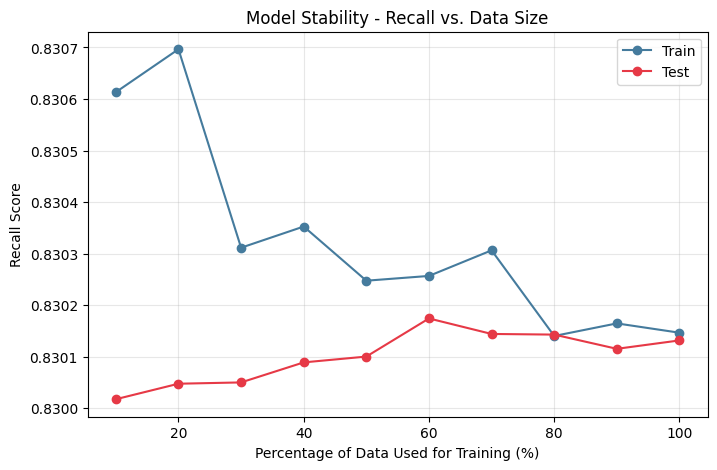

In [79]:
sample_sizes_np = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
train_recalls = []
test_recalls = []

for size in sample_sizes_np:
  n_samples = int(len(Xtr)*size)
  X_subset = Xtr[:n_samples]
  y_subset = ytr[:n_samples]
  xgb = XGBClassifier(eval_metric='logloss', **grid_xgb.best_params_)
  xgb.fit(X_subset, y_subset) 
  train_recalls.append(recall_score(y_subset, xgb.predict(X_subset), average='weighted'))
  test_recalls.append(recall_score(yte, xgb.predict(Xte), average='weighted'))

plt.figure(figsize=(8, 5))
plt.plot(sample_sizes_np * 100, train_recalls, 'o-', label='Train', color='#457B9D')
plt.plot(sample_sizes_np * 100, test_recalls, 'o-', label='Test', color='#E63946')
plt.title("Model Stability - Recall vs. Data Size")
plt.xlabel("Percentage of Data Used for Training (%)")
plt.ylabel("Recall Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Testing the model on data from different years - the year 2014

In [80]:
df_2014 = pd.read_csv(r'E:\data\manipulation_df_2015.csv')
#df_2014 = pd.read_csv('data/manipulation_df_2014.csv')

df_2014.drop(columns=cols_in_groups, inplace=True)

df_2014.head()
print('Data after manipulation', df_2014.shape)

df_sample_2014 = df_2014.sample(frac=0.5, random_state=42)  # sample
print('Sampled data shape', df_sample_2014.shape)

target_col = "Y"

features = ['MAGER14', 'MRACE31', 'MEDUC', 'DMAR', 'MBSTATE_REC', 'RESTATUS', 'PAY',
            'FRACE31', 'FEDUC', 'NO_RISKS', 'CIG_0_R', 'CIG_1_R', 'CIG_2_R',
            'CIG_3_R', 'MHTR', 'BMI', 'BMI_R', 'WTGAIN', 'LBO_REC', 'TBO_REC',
            'PRIORLIVE', 'PRIORDEAD', 'PRIORTERM', 'NO_INFEC', 'LD_ANES', 'ME_PRES',
            'ME_ROUT', 'DMETH_REC', 'RDMETH_REC', 'COMBGEST', 'GESTREC10',
            'GESTREC3', 'BWTR14', 'APGAR5', 'APGAR10', 'DPLURAL', 'NO_ABNORM',
            'NO_CONGEN', 'NO_MMORB', 'T', 'Cardio_Blood', 'Metabolic_Endocrine',
            'Reproductive', 'Digestive', 'Nervous', 'Respiratory',
            'Pregnancy_Complications', 'Infections', 'Labor_Delivery_Interventions',
            'Neonatal_Care', 'Congenital_Anomalies'] #The features that were used in the original model

for col in ["MRACE31", "FRACE31"]: # These columns had some blank values that needed to be handled before converting to numeric
    df_sample_2014[col] = df_sample_2014[col].astype(str).str.strip()
    df_sample_2014[col] = df_sample_2014[col].replace("", np.nan)
    df_sample_2014[col] = pd.to_numeric(df_sample_2014[col], errors="coerce")

    mode_val = df_sample_2014[col].mode(dropna=True)
    if not mode_val.empty:
        df_sample_2014[col] = df_sample_2014[col].fillna(mode_val.iloc[0])

X_2014 = df_sample_2014[features] # Creating the feature matrix for the 2014 data using the same features as the original model
y_2014 = df_sample_2014[target_col]

Data after manipulation (3988733, 64)
Sampled data shape (1994366, 64)


In [81]:
y_pred_best_xgb_2014 = best_xgb_model.predict(X_2014)

accuracy_xgb_best = accuracy_score(y_2014, y_pred_best_xgb_2014)
precision_xgb_best = precision_score(y_2014, y_pred_best_xgb_2014)
recall_xgb_best = recall_score(y_2014, y_pred_best_xgb_2014)
f1_xgb_best = f1_score(y_2014, y_pred_best_xgb_2014)
probs_xgb_best = best_xgb_model.predict_proba(X_2014)[:, 1]
log_loss_xgb_best = log_loss(y_2014, probs_xgb_best)

print("===== XGBoost (tuned) =====")
print(f"Accuracy_XGB: {np.round(accuracy_xgb_best*100,1)}%")
print(f"Precision_XGB: {np.round(precision_xgb_best*100,1)}%")
print(f"Recall_XGB: {np.round(recall_xgb_best*100,1)}%")
print(f"F1_XGB: {np.round(f1_xgb_best*100,1)}%")
print(f"Log Loss_XGB: {log_loss_xgb_best:.6f}")

===== XGBoost (tuned) =====
Accuracy_XGB: 92.6%
Precision_XGB: 6.1%
Recall_XGB: 80.7%
F1_XGB: 11.4%
Log Loss_XGB: 0.262113


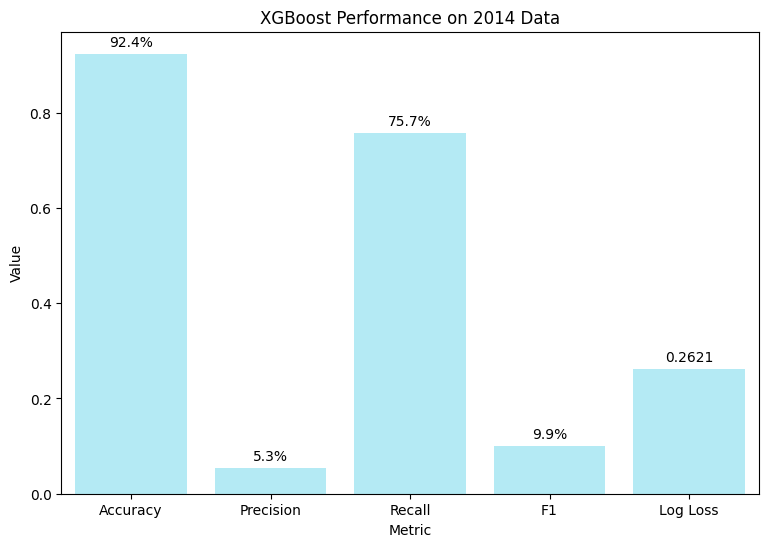

In [82]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "Log Loss"]
values = [accuracy_lr_best,precision_lr_best,recall_lr_best,f1_lr_best,log_loss_xgb_best]

plot_df = pd.DataFrame({"Metric": metrics,"Score": values})

plt.figure(figsize=(9, 6))
ax = sns.barplot(data=plot_df, x="Metric", y="Score", color="#a9f2ff")

plt.title("XGBoost Performance on 2014 Data")
plt.ylabel("Value")

for i, v in enumerate(values):
    if metrics[i] == "Log Loss":
        label = f"{v:.4f}"
    else:
        label = f"{v*100:.1f}%"
    ax.text(i, v + 0.01, label, ha="center", va="bottom")

plt.show()

#del X_2014, y_2014,df_sample_2014,features, df_2014,y_pred_best_lr_2014,data, df_plot
#gc.collect()

The pretty high results shows that the model isn't overfitted

# Causal inference

In [83]:
casual_inference_df = df_numeric.copy() 
casual_inference_df["CIG"] = casual_inference_df["CIG"].apply(lambda x: 0 if x == 0 else 1) 

In [84]:
Y = casual_inference_df["Y"] # The target variable for the causal inference analysis
T = casual_inference_df["CIG"] # The treatment variable for the causal inference analysis
X = casual_inference_df.drop(columns=["Y", "CIG"])

### EDA

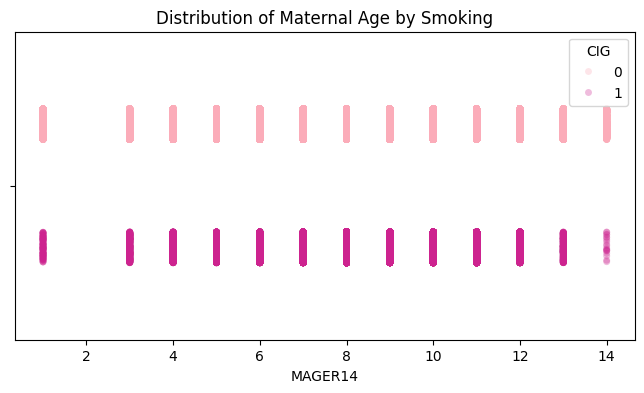

In [85]:
plt.figure(figsize=(8,4))
sns.stripplot(casual_inference_df, x = "MAGER14", dodge = True, hue = "CIG", alpha = 0.3, palette = "RdPu")
plt.title("Distribution of Maternal Age by Smoking")
plt.show()

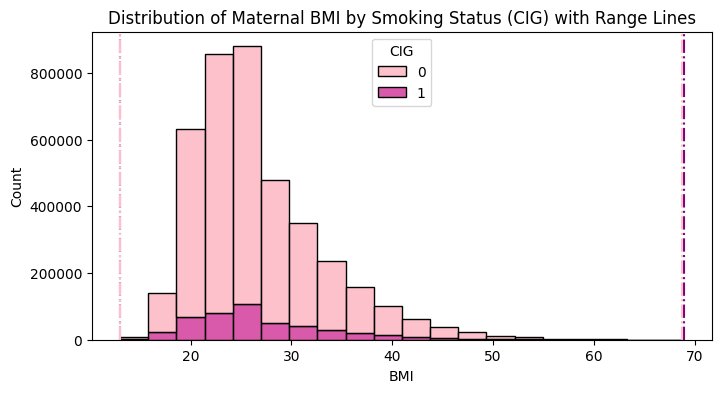

In [86]:
plt.figure(figsize=(8,4))
sns.histplot(data=casual_inference_df, x="BMI", hue="CIG", multiple="stack", palette="RdPu", bins=20)

for cig_status, color in zip([0,1], ["purple", "pink"]):
  group = casual_inference_df[casual_inference_df["CIG"]==cig_status]["BMI"]
  plt.axvline(group.min(), color=color, linestyle="-.", label=f"CIG={cig_status} min")
  plt.axvline(group.max(), color=color, linestyle="-.", label=f"CIG={cig_status} max")

plt.title("Distribution of Maternal BMI by Smoking Status (CIG) with Range Lines")
plt.show()

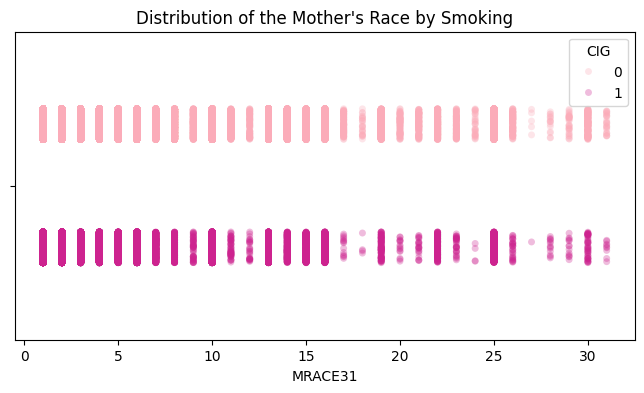

In [87]:
plt.figure(figsize=(8,4))
sns.stripplot(casual_inference_df, x = "MRACE31", dodge = True, hue = "CIG", alpha = 0.3, palette = "RdPu")
plt.title("Distribution of the Mother's Race by Smoking")
plt.show()

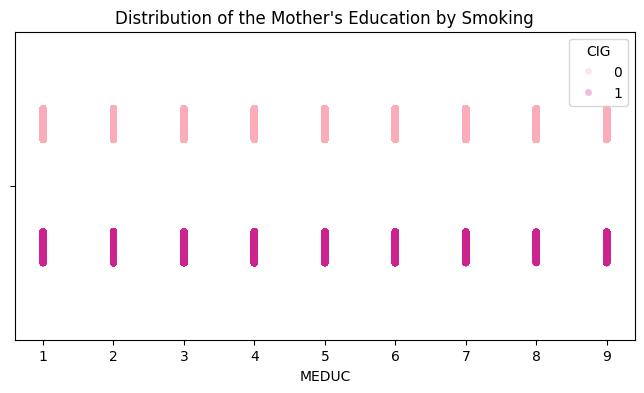

In [88]:
plt.figure(figsize=(8,4))
sns.stripplot(casual_inference_df, x = "MEDUC", dodge = True, hue = "CIG", alpha = 0.3, palette = "RdPu")
plt.title("Distribution of the Mother's Education by Smoking")
plt.show()

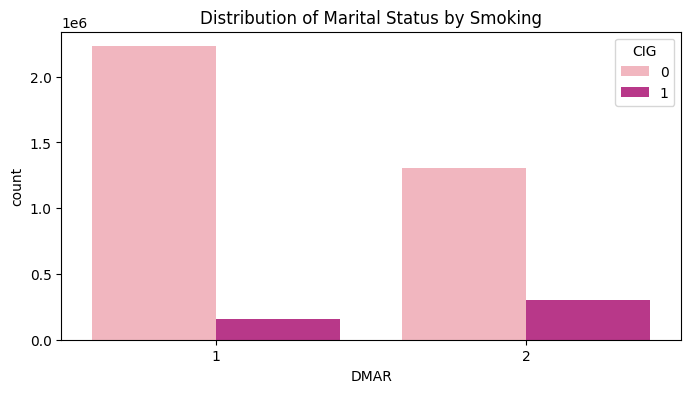

In [89]:
plt.figure(figsize=(8,4))
sns.countplot(casual_inference_df, x = "DMAR", dodge = True, hue = "CIG", palette = "RdPu")
plt.title("Distribution of Marital Status by Smoking")
plt.show()

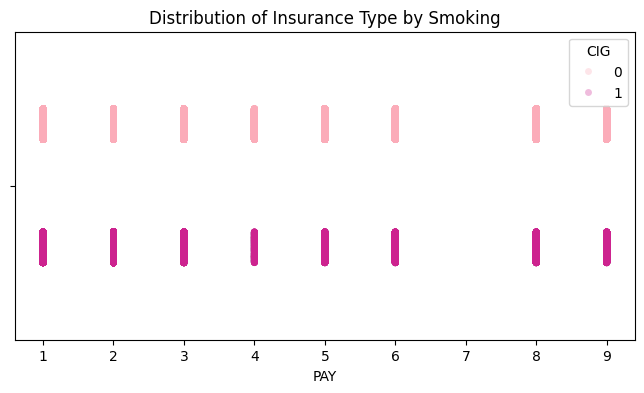

In [90]:
plt.figure(figsize=(8,4))
sns.stripplot(casual_inference_df, x = "PAY", dodge = True, hue = "CIG", alpha = 0.3, palette = "RdPu")
plt.title("Distribution of Insurance Type by Smoking")
plt.show()

## Propensity Score

In [91]:
problem_cols = ['FAGECOMB', 'RF_CESARN', 'PRECARE', 'PREVIS', 'ILLB_R11', 'ILOP_R11', 'ILP_R11']

for col in problem_cols:
    X[col] = X[col].astype(str).str.strip()          # remove whitespace
    X[col] = X[col].replace("", np.nan)              # empty -> NaN
    X[col] = pd.to_numeric(X[col], errors="coerce")  # 01 -> 1, empty -> NaN

# קודי missing ידועים
for col in ["RF_CESARN", "ILLB_R11", "ILOP_R11", "ILP_R11"]:
    X[col] = X[col].replace([88, 99, 888], np.nan)

# מילוי לפי mode
for col in problem_cols:
    mode_val = X[col].mode(dropna=True)
    if not mode_val.empty:
        X[col] = X[col].fillna(mode_val.iloc[0])

print(X.dtypes.value_counts())
print(X.select_dtypes(exclude=["int64", "float64"]).columns.tolist())
print("NaNs in X:", X.isna().sum().sum())

float64    31
int64      22
Name: count, dtype: int64
[]
NaNs in X: 0


In [92]:
# The propensity score is the probability of receiving treatment T given X

Xtr, X_cal, ttr, t_cal = train_test_split(X, T, test_size=0.3, random_state=42)

rf = RandomForestClassifier(n_estimators=500,max_depth=None,min_samples_leaf=10,random_state=42,n_jobs=-1)

rf.fit(Xtr, ttr)
propensity_scores = rf.predict_proba(X)[:, 1]

propensity_df = pd.DataFrame({"propensity_score": propensity_scores})

propensity_df.head()

,propensity_score
0,0.059699
1,0.030069
2,0.134464
3,0.029681
4,0.044701


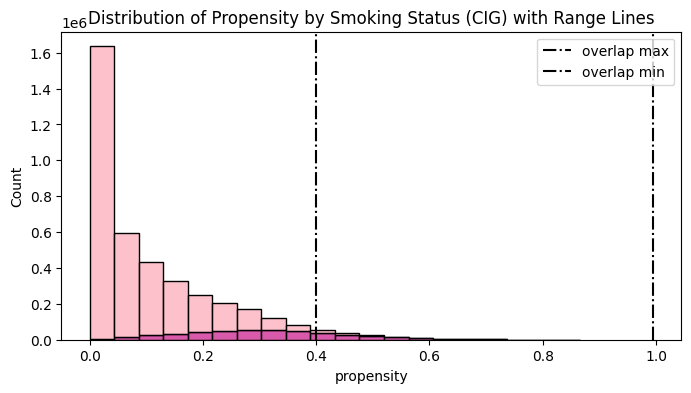

In [93]:
casual_inference_df['propensity'] = propensity_scores

plt.figure(figsize=(8,4))
sns.histplot(data=casual_inference_df,x="propensity",hue="CIG",multiple="stack",palette="RdPu",bins=20)

plt.axvline(0.995, color="black", linestyle="-.", label="overlap max") # Fit to overlap
plt.axvline(0.399, color="black", linestyle="-.", label="overlap min") # Fit to overlap

plt.title("Distribution of Propensity by Smoking Status (CIG) with Range Lines")
plt.legend()
plt.show()

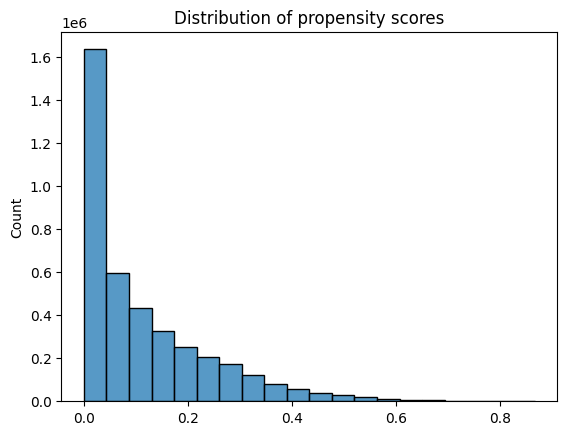

In [94]:
sns.histplot(propensity_scores, bins=20)
plt.title("Distribution of propensity scores")
plt.show()

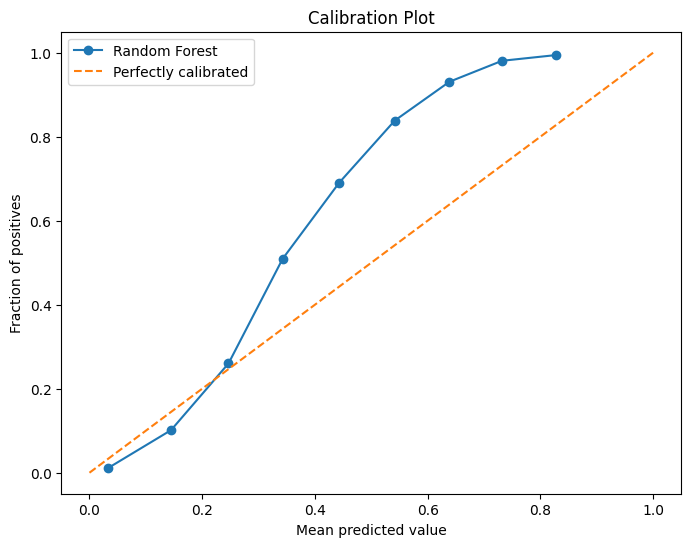

In [95]:
# Calibration curve
fraction_of_positives, mean_predicted_value = calibration_curve(T, propensity_scores, n_bins=10)

# Plot the calibration curve
plt.figure(figsize=(8, 6))
plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label='Random Forest')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')
plt.xlabel('Mean predicted value')
plt.ylabel('Fraction of positives')
plt.title('Calibration Plot')
plt.legend()
plt.show()

In [96]:
# מכיילים עם isotonic
calibrated_model = CalibratedClassifierCV(rf, method="isotonic", cv="prefit")

calibrated_model.fit(X_cal, t_cal)
propensity_calibrated = calibrated_model.predict_proba(X)[:, 1]

In [97]:
casual_inference_df['propensity'] = propensity_calibrated

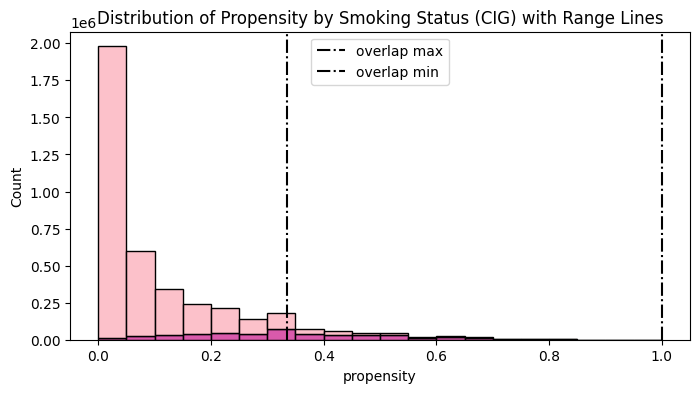

In [98]:
plt.figure(figsize=(8,4))
sns.histplot(data=casual_inference_df,x="propensity",hue="CIG",multiple="stack",palette="RdPu",bins=20)

plt.axvline(1, color="black", linestyle="-.", label="overlap max") #fit to overlap
plt.axvline(0.335, color="black", linestyle="-.", label="overlap min") #fit to overlap

plt.title("Distribution of Propensity by Smoking Status (CIG) with Range Lines")
plt.legend()
plt.show()

In [99]:
diff = len(casual_inference_df)
casual_inference_df = casual_inference_df[(casual_inference_df['propensity'] >= 0.335) & (casual_inference_df['propensity'] <= 1)]
diff -= len(casual_inference_df)
print(f"Removed {diff} rows")

Removed 3640035 rows


In [100]:
propensity_df = casual_inference_df.copy()
casual_inference_df = casual_inference_df.drop(columns=["propensity"])

In [101]:
Y = casual_inference_df["Y"]
T = casual_inference_df["CIG"]
X = casual_inference_df.drop(columns=["Y", "CIG"])

problem_cols = ['FAGECOMB', 'RF_CESARN', 'PRECARE', 'PREVIS', 'ILLB_R11', 'ILOP_R11', 'ILP_R11']

for col in problem_cols:
    X[col] = X[col].astype(str).str.strip()
    X[col] = X[col].replace("", np.nan)
    X[col] = pd.to_numeric(X[col], errors="coerce")

for col in ["RF_CESARN", "ILLB_R11", "ILOP_R11", "ILP_R11"]:
    X[col] = X[col].replace([88, 99, 888], np.nan)

for col in problem_cols:
    mode_val = X[col].mode(dropna=True)
    if not mode_val.empty:
        X[col] = X[col].fillna(mode_val.iloc[0])

print(X.dtypes.value_counts())
print(X.select_dtypes(exclude=["int64", "float64"]).columns.tolist())
print("NaNs in X:", X.isna().sum().sum())

float64    31
int64      22
Name: count, dtype: int64
[]
NaNs in X: 0


## T-Learner

In [102]:
# The T-learner approach involves training separate models for the treated and control groups to estimate the treatment effect.

model_1 = RandomForestRegressor()
model_1.fit(X[T == 1], Y[T == 1])

model_0 = RandomForestRegressor()
model_0.fit(X[T == 0], Y[T == 0])

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [103]:
predicted_outcome_if_smoker = model_1.predict(X)
predicted_outcome_if_non_smoker = model_0.predict(X)

individual_treatment_effect = predicted_outcome_if_smoker - predicted_outcome_if_non_smoker

In [104]:
ATE_T = individual_treatment_effect.mean()
print("ATE:", ATE_T)

ATE: 0.0009622284012171538


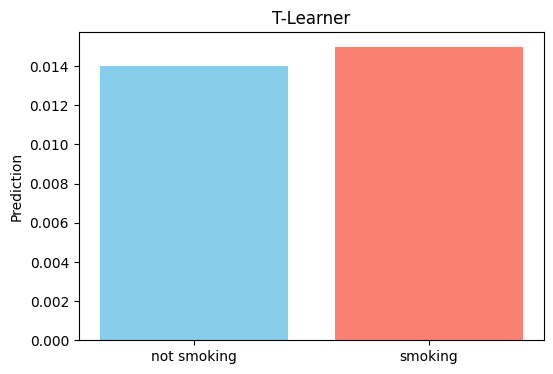

In [105]:
plt.figure(figsize=(6,4))
treated_mean_T = predicted_outcome_if_smoker.mean()
control_mean_T = predicted_outcome_if_non_smoker.mean()

plt.bar([0,1], [control_mean_T, treated_mean_T], color=['skyblue', 'salmon'])
plt.xticks([0,1], ['not smoking', 'smoking'])
plt.ylabel("Prediction")
plt.title(f"T-Learner")
plt.show()

## S-Learner

In [106]:
# The S-learner approach involves training a single model that includes the treatment variable as a feature to estimate the treatment effect.

X_with_T = X.copy()
X_with_T["CIG"] = T

Xtr, Xte, ytr, yte = train_test_split(X_with_T, Y, test_size=0.2, random_state=42)

model_s = RandomForestRegressor(random_state=42)
model_s.fit(Xtr, ytr)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [107]:
# עותק שבו כולם מעשנים
Xte_1 = Xte.copy()
Xte_1["CIG"] = 1

# עותק שבו כולם לא מעשנים
Xte_0 = Xte.copy()
Xte_0["CIG"] = 0

In [108]:
predicted_outcome_if_smoker = model_s.predict(Xte_1)
predicted_outcome_if_non_smoker = model_s.predict(Xte_0)

individual_treatment_effect = predicted_outcome_if_smoker - predicted_outcome_if_non_smoker

In [109]:
ATE_S = np.mean(individual_treatment_effect)
print("ATE:", ATE_S)

ATE: 0.0010519787783194725


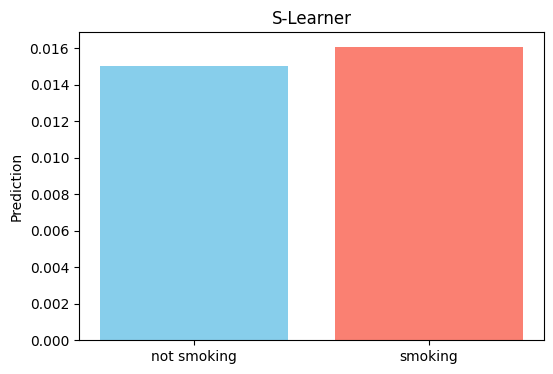

In [110]:
plt.figure(figsize=(6,4))
treated_mean_S = predicted_outcome_if_smoker.mean()
control_mean_S = predicted_outcome_if_non_smoker.mean()

plt.bar([0,1], [control_mean_S, treated_mean_S], color=['skyblue', 'salmon'])
plt.xticks([0,1], ['not smoking', 'smoking'])
plt.ylabel("Prediction")
plt.title(f"S-Learner")
plt.show()

## matching

In [111]:
# Matching is a method used in causal inference to create a balanced dataset by pairing treated and control units that have 
# similar propensity scores, which helps to reduce confounding bias when estimating treatment effects.

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

prop_model = LogisticRegression(max_iter=5000)
prop_model.fit(X_scaled, T)
propensity_scores = prop_model.predict_proba(X_scaled)[:,1]
propensity_df["propensity"] = propensity_scores

In [112]:
# Divided into treatment and control groups

treated = propensity_df[propensity_df["Y"]==1].copy()
control = propensity_df[propensity_df["Y"]==0].copy()

# Find the closest ones by propensity
nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[["propensity"]])
distances, indices = nn.kneighbors(treated[["propensity"]])

# Create a matched dataset
matched_controls = control.iloc[indices.flatten()].copy()
matched_treated = treated.copy()

matched_df = pd.concat([matched_treated, matched_controls], ignore_index=True)

In [113]:
ATE_M = matched_df[matched_df["T"]==1]["Y"].mean() - matched_df[matched_df["T"]==0]["Y"].mean()
print("ATE after matching:", ATE_M)

ATE after matching: -0.04007469144528747


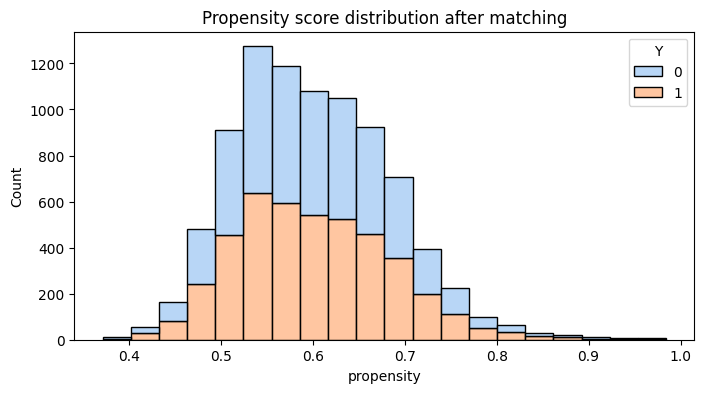

In [114]:
plt.figure(figsize=(8,4))
sns.histplot(data=matched_df, x="propensity", hue="Y", bins=20, multiple="stack", palette = "pastel")
plt.title("Propensity score distribution after matching")
plt.show()

The graph shows whether the overlap between treated and control is good – that is, whether the match was successful.

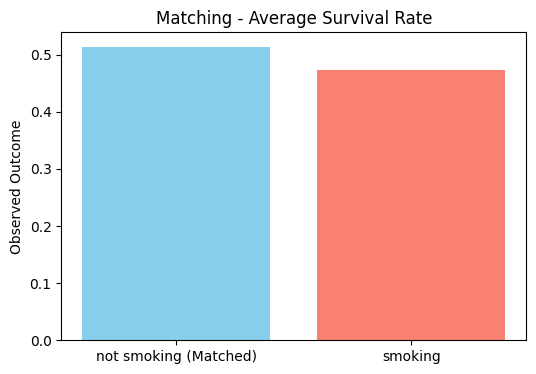

In [115]:
plt.figure(figsize=(6,4))

mean_treated_M = matched_df[matched_df["T"] == 1]["Y"].mean()
mean_control_M = matched_df[matched_df["T"] == 0]["Y"].mean()

plt.bar([0, 1], [mean_control_M, mean_treated_M], color=['skyblue', 'salmon'])
plt.xticks([0, 1], ['not smoking (Matched)', 'smoking'])
plt.ylabel("Observed Outcome")
plt.title("Matching - Average Survival Rate")
plt.show()

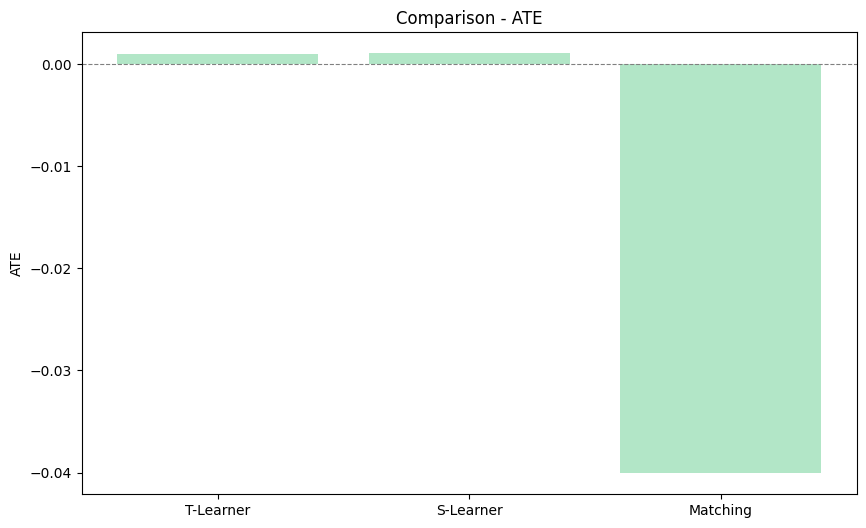

In [116]:
models = ["T-Learner", "S-Learner", "Matching"]

ATE_values = [ATE_T, ATE_S, ATE_M]

plt.figure(figsize=(10,6))
plt.bar(models, ATE_values, color="#B2E6C7")
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
plt.ylabel("ATE")
plt.title("Comparison - ATE")
plt.show()